# Baseline vs classic vectorisation methods

This notebook compares the existing baseline against classic non-ML vectorisation algorithms.

All methods receive the **same shared preprocessed raster** so the comparison is fair:

1. raw synthetic engineering-style raster;
2. shared thresholding and Zhang-Suen thinning/skeletonisation;
3. method-specific vectorisation only after preprocessing.

Compared methods:

- Baseline
- Hough Transform
- Contour-based fitting
- Thinning / skeletonisation graph tracing
- Run-graph based vectorisation
- Sparse-pixel RANSAC vectorisation
- Mesh-pattern local vectorisation

Exports are written to the folder `classic-learning`.


In [20]:
import random
import math
from pathlib import Path
from collections import deque

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown


from matplotlib.backends.backend_pdf import PdfPages

# New data every time by default.
# Set SEED to an integer, for example 42, when you want repeatable comparisons.
SEED = None
if SEED is not None:
    random.seed(SEED)
    np.random.seed(SEED)

IMG_SIZE = 128
MAX_VECTORS = 20
LINE_WIDTH = 1

# Training images are only kept so the original synthetic-data preview still works.
# No machine-learning model is trained in this notebook.
N_TRAIN_IMAGES = 20   # no training; used only for quick synthetic preview
N_TEST = 25           # increase for a larger benchmark

PATCH_SIZE = 9
PATCH_RADIUS = PATCH_SIZE // 2
JUNCTION_RADIUS = 2

# Controls the final vector cleanup.
MIN_VECTOR_LENGTH = 2.0
MAX_MERGE_PASSES = 2

# Requested output folder.
EXPORT_DIR = Path('classic-learning')
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

print('Classic vectorisation comparison only. No MLP/CNN training will run.')
print('Exports:', EXPORT_DIR.resolve())


Classic vectorisation comparison only. No MLP/CNN training will run.
Exports: C:\Users\elmak\Documents\GitHub\Understanding-Artificial-Intelligence\vectorization-project\classic-learning


## Engineering drawing geometry configuration

These controls make the synthetic data and the final evaluation prefer engineering-style geometry: whole-degree angles, whole-pixel lengths, and stronger weighting for 90°, then 45°, 60°, 30°, and 10° angle families.


In [2]:
# Engineering drawing geometry controls
# These weights are deliberately easy to edit.
# A higher weight means mistakes on that angle family matter more, and data generation samples it more often.
GEOMETRY_CONFIG = {
    "angle_unit_deg": 1,          # all angles are rounded to whole degrees
    "length_unit_px": 1,          # all lengths are rounded to whole pixels
    "angle_unit_weights": {
        90: 5.0,                  # strongest preference: horizontal/vertical/right-angle work
        45: 3.0,
        60: 2.0,
        30: 1.5,
        10: 1.0,
        1: 0.25,                  # fallback: any whole-degree angle
    },
    "line_angle_tolerance_deg": 5.0,
    "junction_angle_tolerance_deg": 5.0,
    "length_tolerance_ratio": 0.15,
    "score_weights": {
        "line_geometry": 0.45,
        "total_length": 0.20,
        "junction_angles": 0.25,
        "vector_count": 0.10,
    },
}


def snap_angle_deg(angle_deg, unit_deg=None):
    """Snap an undirected line angle to the configured angle unit."""
    if unit_deg is None:
        unit_deg = GEOMETRY_CONFIG["angle_unit_deg"]
    return (round(angle_deg / unit_deg) * unit_deg) % 180


def snap_length_px(length_px, unit_px=None):
    """Snap a vector length to the configured pixel unit."""
    if unit_px is None:
        unit_px = GEOMETRY_CONFIG["length_unit_px"]
    return max(unit_px, round(length_px / unit_px) * unit_px)


def sample_weighted_angle_deg(config=GEOMETRY_CONFIG):
    """Sample a whole-degree engineering angle using the configured angle-family weights."""
    units = list(config["angle_unit_weights"].keys())
    weights = list(config["angle_unit_weights"].values())
    chosen_unit = random.choices(units, weights=weights, k=1)[0]

    # For line geometry, 0 and 180 degrees describe the same orientation.
    # We later add 180 randomly so the vector can point either way.
    if chosen_unit <= 1:
        base = random.randint(0, 179)
    else:
        candidates = list(range(0, 180, chosen_unit))
        base = random.choice(candidates)

    directed_angle = base + random.choice([0, 180])
    return round(directed_angle / config["angle_unit_deg"]) * config["angle_unit_deg"]


## 1. Synthetic vector data

Synthetic generator is changed here:

- line endpoints are integer pixel-centre grid points, from `0` to `IMG_SIZE - 1`;
- line direction is sampled from weighted engineering angle families, highest priority first: 90°, 45°, 60°, 30°;
- stroke weight varies per line between 0.5 and 3 pixels;
- dataset size, number of random items per image, stroke fading, and raster noise are editable in `SYNTHETIC_DATA_CONFIG`.


(20, 128, 128) 20
Synthetic data controls:
{'n_train_images': 20, 'n_test_images': 25, 'min_items_per_image': 1, 'max_items_per_image': 20, 'min_line_length_px': 12, 'margin_px': 4, 'line_width_range_px': (0.5, 3.0), 'stroke_fade_range': (0.9, 1.0), 'raster_noise_std': 0.0, 'angle_family_weights': {90: 8.0, 45: 4.0, 60: 2.0, 30: 1.0}, 'angle_rounding_deg': 1, 'max_line_generation_attempts': 1000}

Example line styles for first training image:
  line 0: {'width_px': 2.067, 'darkness': 0.964, 'angle_family': 90, 'target_angle_deg': 0, 'actual_angle_deg': 0.0}
  line 1: {'width_px': 1.587, 'darkness': 0.945, 'angle_family': 90, 'target_angle_deg': 90, 'actual_angle_deg': 90.0}
  line 2: {'width_px': 1.59, 'darkness': 0.972, 'angle_family': 90, 'target_angle_deg': 90, 'actual_angle_deg': 90.0}
  line 3: {'width_px': 1.869, 'darkness': 0.912, 'angle_family': 60, 'target_angle_deg': 120, 'actual_angle_deg': 119.982}
  line 4: {'width_px': 0.654, 'darkness': 0.96, 'angle_family': 90, 'target_

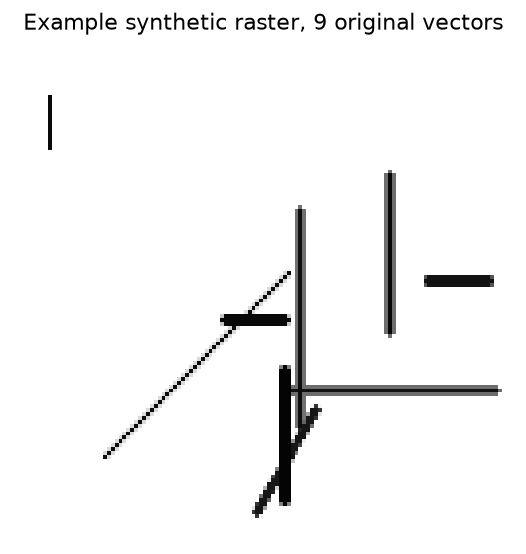

In [3]:
def clip_point(x, y, img_size=IMG_SIZE):
    """Clip a point to the valid pixel-centre grid: 0 ... img_size - 1."""
    return int(np.clip(round(x), 0, img_size - 1)), int(np.clip(round(y), 0, img_size - 1))


# Synthetic-data controls.
# Edit only this dictionary when you want more/fewer examples, more/fewer lines,
# more/less stroke fade, or more/less raster noise.
SYNTHETIC_DATA_CONFIG = {
    "n_train_images": N_TRAIN_IMAGES,   # number of random training drawings to create
    "n_test_images": N_TEST,            # number of random test drawings to create

    "min_items_per_image": 1,           # minimum random line items in one drawing
    "max_items_per_image": MAX_VECTORS, # maximum random line items in one drawing

    "min_line_length_px": 12,           # measured between integer pixel-centre endpoints
    "margin_px": 4,                     # keep endpoints away from the image border

    "line_width_range_px": (0.5, 3.0),  # variable raster stroke weight per line
    "stroke_fade_range": (0.90, 1.00),  # 1.0 = black/strong, lower values = faded/lighter
    "raster_noise_std": 0.00,           # try 0.02, 0.05, 0.10 for increasing Gaussian noise

    # Angle-family priority. The selected family creates angles that are multiples of that degree.
    # Because 90-degree angles also appear inside 45/60/30 families, they naturally occur often.
    "angle_family_weights": {
        90: 8.0,   # highest priority: horizontal/vertical/right-angle drawing
        45: 4.0,
        60: 2.0,
        30: 1.0,
    },

    # Endpoints must be grid points, so 30/60 degree lines are represented by the closest
    # integer endpoint vector whose rounded angle is still the requested whole-degree angle.
    "angle_rounding_deg": 1,
    "max_line_generation_attempts": 1000,
}

# Keep the original global names consistent for all later notebook cells.
N_TRAIN_IMAGES = SYNTHETIC_DATA_CONFIG["n_train_images"]
N_TEST = SYNTHETIC_DATA_CONFIG["n_test_images"]
MAX_VECTORS = SYNTHETIC_DATA_CONFIG["max_items_per_image"]


def bresenham_line(x0, y0, x1, y1):
    """Return integer grid pixels touched by a 1-pixel digital line."""
    x0, y0, x1, y1 = map(int, [x0, y0, x1, y1])
    points = []
    dx = abs(x1 - x0)
    dy = -abs(y1 - y0)
    sx = 1 if x0 < x1 else -1
    sy = 1 if y0 < y1 else -1
    err = dx + dy
    x, y = x0, y0
    while True:
        points.append((x, y))
        if x == x1 and y == y1:
            break
        e2 = 2 * err
        if e2 >= dy:
            err += dy
            x += sx
        if e2 <= dx:
            err += dx
            y += sy
    return points


def pixel_distance_to_segment_grid(x0, y0, x1, y1, img_size=IMG_SIZE):
    """Distance from every pixel centre to a finite line segment."""
    yy, xx = np.mgrid[0:img_size, 0:img_size].astype(np.float32)
    x0, y0, x1, y1 = map(float, [x0, y0, x1, y1])
    vx, vy = x1 - x0, y1 - y0
    denom = vx * vx + vy * vy
    if denom <= 1e-12:
        return np.hypot(xx - x0, yy - y0)

    t = ((xx - x0) * vx + (yy - y0) * vy) / denom
    t = np.clip(t, 0.0, 1.0)
    qx = x0 + t * vx
    qy = y0 + t * vy
    return np.hypot(xx - qx, yy - qy)


def rasterise_vectors(
    vectors,
    img_size=IMG_SIZE,
    line_width=LINE_WIDTH,
    line_styles=None,
    add_noise=False,
    noise_std=None,
):
    """Rasterise vectors onto a white image.

    Important compatibility rule:
    - rasterise_vectors(pred_vectors, IMG_SIZE) keeps the original 1-pixel Bresenham binary output.
    - synthetic input images pass line_styles, enabling variable width, fading, and optional noise.
    """
    image = np.ones((img_size, img_size), dtype=np.float32)

    # Preserve the original downstream behaviour for predictions and metric rasters.
    if line_styles is None and line_width == LINE_WIDTH and not add_noise:
        for vector in vectors:
            x0, y0, x1, y1 = vector[:4]
            x0, y0 = clip_point(x0, y0, img_size)
            x1, y1 = clip_point(x1, y1, img_size)
            for x, y in bresenham_line(x0, y0, x1, y1):
                image[y, x] = 0.0
        return image.astype(np.float32)

    if line_styles is None:
        line_styles = [{} for _ in vectors]

    for vector, style in zip(vectors, line_styles):
        x0, y0, x1, y1 = vector[:4]
        x0, y0 = clip_point(x0, y0, img_size)
        x1, y1 = clip_point(x1, y1, img_size)

        width_px = float(style.get("width_px", line_width))
        darkness = float(style.get("darkness", 1.0))
        width_px = max(0.01, width_px)
        darkness = float(np.clip(darkness, 0.0, 1.0))

        # A soft half-pixel edge keeps fractional weights such as 0.5 visible.
        dist = pixel_distance_to_segment_grid(x0, y0, x1, y1, img_size)
        half_width = width_px / 2.0
        edge_softness = 0.5
        coverage = np.clip((half_width + edge_softness - dist) / edge_softness, 0.0, 1.0)

        # Darken the raster where this stroke exists. Overlapping strokes remain dark.
        image = np.minimum(image, 1.0 - darkness * coverage)

    if add_noise:
        if noise_std is None:
            noise_std = SYNTHETIC_DATA_CONFIG["raster_noise_std"]
        noise_std = float(noise_std)
        if noise_std > 0:
            image = image + np.random.normal(0.0, noise_std, image.shape).astype(np.float32)
            image = np.clip(image, 0.0, 1.0)

    return image.astype(np.float32)


def line_angle_deg(vector):
    x0, y0, x1, y1 = vector[:4]
    return math.degrees(math.atan2(y1 - y0, x1 - x0)) % 180


def rounded_line_angle_deg(vector, rounding_deg=1):
    angle = line_angle_deg(vector)
    return (round(angle / rounding_deg) * rounding_deg) % 180


def sample_angle_family(config=SYNTHETIC_DATA_CONFIG):
    families = list(config["angle_family_weights"].keys())
    weights = list(config["angle_family_weights"].values())
    family = random.choices(families, weights=weights, k=1)[0]

    # For a family value of 45, choose from 0, 45, 90, 135.
    # For 30, choose from 0, 30, 60, 90, 120, 150.
    base_angles = list(range(0, 180, int(family)))
    target_angle = random.choice(base_angles)

    # Randomly reverse direction while preserving the undirected line angle.
    directed_angle = target_angle + random.choice([0, 180])
    return family, target_angle, directed_angle


def make_grid_endpoint_vector(x0, y0, length_px, directed_angle_deg):
    """Convert a sampled angle/length into integer pixel-centre endpoints."""
    angle_rad = math.radians(directed_angle_deg)
    dx = int(round(math.cos(angle_rad) * length_px))
    dy = int(round(math.sin(angle_rad) * length_px))
    return int(x0), int(y0), int(x0 + dx), int(y0 + dy)


def random_line(img_size=IMG_SIZE, min_len=None, config=SYNTHETIC_DATA_CONFIG):
    """Generate one engineering-style vector with integer pixel-centre endpoints.

    The returned vector is always a 4-tuple `(x0, y0, x1, y1)` so all later notebook
    code remains compatible. Per-line raster style is returned separately.
    """
    if min_len is None:
        min_len = int(config["min_line_length_px"])

    margin = int(config["margin_px"])
    max_len = max(min_len, img_size - 1 - 2 * margin)
    rounding_deg = int(config["angle_rounding_deg"])

    for _ in range(int(config["max_line_generation_attempts"])):
        family, target_angle, directed_angle = sample_angle_family(config)
        length_px = random.randint(min_len, max_len)

        x0 = random.randint(margin, img_size - 1 - margin)
        y0 = random.randint(margin, img_size - 1 - margin)
        vector = make_grid_endpoint_vector(x0, y0, length_px, directed_angle)
        x0, y0, x1, y1 = vector

        if not (margin <= x1 <= img_size - 1 - margin and margin <= y1 <= img_size - 1 - margin):
            continue

        if math.hypot(x1 - x0, y1 - y0) < min_len:
            continue

        # Because endpoints are constrained to integer grid points, exact 30/60 degree
        # trigonometric coordinates are not always possible. This keeps the rounded
        # whole-degree angle constrained to the sampled target.
        if rounded_line_angle_deg(vector, rounding_deg) != target_angle % 180:
            continue

        line_width = random.uniform(*config["line_width_range_px"])
        darkness = random.uniform(*config["stroke_fade_range"])
        style = {
            "width_px": line_width,
            "darkness": darkness,
            "angle_family": family,
            "target_angle_deg": target_angle,
            "actual_angle_deg": line_angle_deg(vector),
        }
        return vector, style

    # Fallback: a clean horizontal grid-aligned line.
    y = margin
    vector = (margin, y, img_size - 1 - margin, y)
    style = {
        "width_px": float(np.mean(config["line_width_range_px"])),
        "darkness": float(np.mean(config["stroke_fade_range"])),
        "angle_family": 90,
        "target_angle_deg": 0,
        "actual_angle_deg": 0.0,
    }
    return vector, style


def generate_sample(max_vectors=None, img_size=IMG_SIZE, config=SYNTHETIC_DATA_CONFIG):
    if max_vectors is None:
        max_vectors = int(config["max_items_per_image"])

    min_items = int(config["min_items_per_image"])
    max_items = int(max_vectors)
    n = random.randint(min_items, max_items)

    vectors = []
    line_styles = []
    for _ in range(n):
        vector, style = random_line(img_size=img_size, config=config)
        vectors.append(vector)
        line_styles.append(style)

    image = rasterise_vectors(
        vectors,
        img_size=img_size,
        line_styles=line_styles,
        add_noise=True,
        noise_std=config["raster_noise_std"],
    )
    return image, vectors, line_styles


def generate_dataset(n_samples, return_styles=False, config=SYNTHETIC_DATA_CONFIG):
    images, vectors, styles = [], [], []
    for _ in range(int(n_samples)):
        img, vec, line_styles = generate_sample(config=config)
        images.append(img)
        vectors.append(vec)
        styles.append(line_styles)

    if return_styles:
        return np.stack(images), vectors, styles
    return np.stack(images), vectors


train_images, train_vectors, train_line_styles = generate_dataset(
    SYNTHETIC_DATA_CONFIG["n_train_images"],
    return_styles=True,
)
test_images, test_vectors, test_line_styles = generate_dataset(
    SYNTHETIC_DATA_CONFIG["n_test_images"],
    return_styles=True,
)

print(train_images.shape, len(train_vectors))
print('Synthetic data controls:')
print(SYNTHETIC_DATA_CONFIG)
print('\nExample line styles for first training image:')
for i, style in enumerate(train_line_styles[0]):
    print(f'  line {i}:', {k: round(v, 3) if isinstance(v, float) else v for k, v in style.items()})

plt.figure(figsize=(5, 5), dpi=130)
plt.imshow(train_images[0], cmap='gray', vmin=0, vmax=1, interpolation='nearest')
plt.title(f'Example synthetic raster, {len(train_vectors[0])} original vectors')
plt.axis('off')
plt.show()


## Original segment-intersection helper

Reused unchanged because the engineering junction-angle metric depends on it.

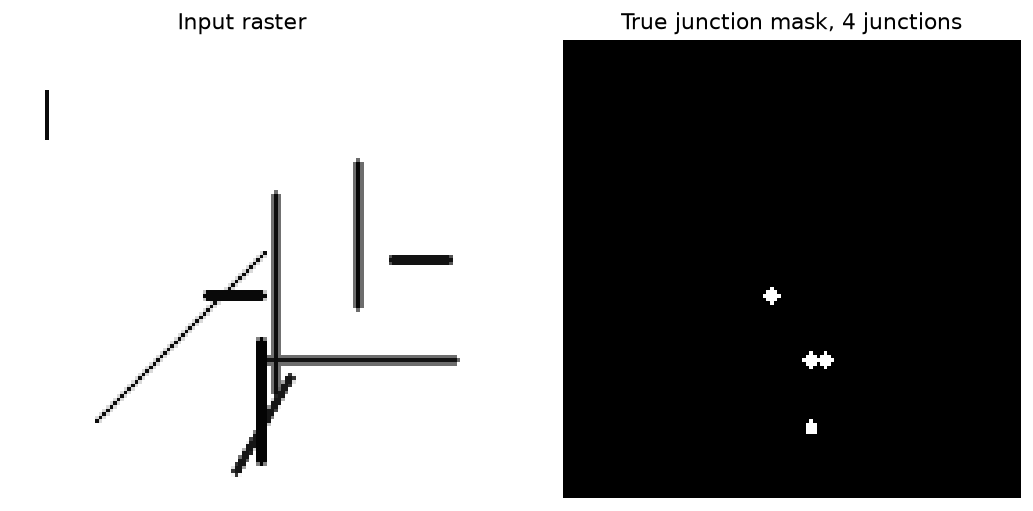

In [4]:
def segment_intersection(a, b, eps=1e-9):
    x1, y1, x2, y2 = map(float, a)
    x3, y3, x4, y4 = map(float, b)
    den = (x1 - x2) * (y3 - y4) - (y1 - y2) * (x3 - x4)
    if abs(den) < eps:
        return None
    px = ((x1*y2 - y1*x2) * (x3 - x4) - (x1 - x2) * (x3*y4 - y3*x4)) / den
    py = ((x1*y2 - y1*x2) * (y3 - y4) - (y1 - y2) * (x3*y4 - y3*x4)) / den

    def between(p, q, r):
        return min(p, r) - 1e-6 <= q <= max(p, r) + 1e-6

    if between(x1, px, x2) and between(y1, py, y2) and between(x3, px, x4) and between(y3, py, y4):
        return px, py
    return None


def junction_mask_from_vectors(vectors, img_size=IMG_SIZE, radius=JUNCTION_RADIUS):
    mask = np.zeros((img_size, img_size), dtype=np.float32)
    points = []
    for i in range(len(vectors)):
        for j in range(i + 1, len(vectors)):
            p = segment_intersection(vectors[i], vectors[j])
            if p is not None:
                points.append(p)
                cx, cy = p
                for y in range(max(0, int(cy - radius)), min(img_size, int(cy + radius) + 1)):
                    for x in range(max(0, int(cx - radius)), min(img_size, int(cx + radius) + 1)):
                        if (x - cx) ** 2 + (y - cy) ** 2 <= radius ** 2:
                            mask[y, x] = 1.0
    return mask, points

train_junction_masks = []
for vecs in train_vectors:
    m, _ = junction_mask_from_vectors(vecs)
    train_junction_masks.append(m)
train_junction_masks = np.stack(train_junction_masks)

sample_idx = 0
jm, pts = junction_mask_from_vectors(train_vectors[sample_idx])
fig, ax = plt.subplots(1, 2, figsize=(10, 5), dpi=130)
ax[0].imshow(train_images[sample_idx], cmap='gray', vmin=0, vmax=1, interpolation='nearest')
ax[0].set_title('Input raster')
ax[1].imshow(jm, cmap='gray', vmin=0, vmax=1, interpolation='nearest')
ax[1].set_title(f'True junction mask, {len(pts)} junctions')
for a in ax:
    a.axis('off')
plt.show()

## Original baseline helpers

These definitions keep the original baseline junction rule: `neighbour_count >= 3` followed by `expand_mask(radius=1)`.

In [5]:
def threshold_stroke(image):
    return (image <= 0.5).astype(np.uint8)


def neighbour_count(mask, y, x):
    h, w = mask.shape
    c = 0
    for dy in (-1, 0, 1):
        for dx in (-1, 0, 1):
            if dx == 0 and dy == 0:
                continue
            yy, xx = y + dy, x + dx
            if 0 <= yy < h and 0 <= xx < w and mask[yy, xx]:
                c += 1
    return c


def baseline_graph_junction_mask(image):
    # EXACT same rule as the original baseline: threshold -> neighbour_count >= 3 -> expand radius 1.
    stroke = threshold_stroke(image)
    out = np.zeros_like(stroke, dtype=np.uint8)
    ys, xs = np.where(stroke == 1)
    for y, x in zip(ys, xs):
        if neighbour_count(stroke, y, x) >= 3:
            out[y, x] = 1
    return expand_mask(out, radius=1)


def expand_mask(mask, radius=1):
    out = mask.copy().astype(np.uint8)
    ys, xs = np.where(mask > 0)
    h, w = mask.shape
    for y, x in zip(ys, xs):
        for yy in range(max(0, y - radius), min(h, y + radius + 1)):
            for xx in range(max(0, x - radius), min(w, x + radius + 1)):
                if (yy - y) ** 2 + (xx - x) ** 2 <= radius ** 2:
                    out[yy, xx] = 1
    return out

## 6. Junction-aware vector reconstruction

This is the key change. Instead of creating many tiny line pieces inside a junction cluster, the algorithm contracts each predicted junction region to a single node and traces arms out from it.

This gives a middle ground:

- it does not delete the junction, so gaps are reduced;
- it does not fit many tiny lines inside the junction, so visual clutter is reduced.

In [6]:
NEIGHBOURS_8 = [
    (-1, -1), (0, -1), (1, -1),
    (-1,  0),          (1,  0),
    (-1,  1), (0,  1), (1,  1),
]


def connected_components(mask):
    mask = mask.astype(bool)
    h, w = mask.shape
    seen = np.zeros_like(mask, dtype=bool)
    comps = []
    for y in range(h):
        for x in range(w):
            if not mask[y, x] or seen[y, x]:
                continue
            q = deque([(y, x)])
            seen[y, x] = True
            comp = []
            while q:
                cy, cx = q.popleft()
                comp.append((cy, cx))
                for dx, dy in NEIGHBOURS_8:
                    ny, nx = cy + dy, cx + dx
                    if 0 <= ny < h and 0 <= nx < w and mask[ny, nx] and not seen[ny, nx]:
                        seen[ny, nx] = True
                        q.append((ny, nx))
            comps.append(comp)
    return comps


def make_node_map(stroke, junction_mask):
    h, w = stroke.shape
    node_map = -np.ones((h, w), dtype=np.int32)
    nodes = []

    # Junction nodes from connected predicted junction regions.
    for comp in connected_components(junction_mask & stroke):
        if len(comp) == 0:
            continue
        ys = np.array([p[0] for p in comp], dtype=np.float32)
        xs = np.array([p[1] for p in comp], dtype=np.float32)
        node_id = len(nodes)
        nodes.append({'type': 'junction', 'x': float(xs.mean()), 'y': float(ys.mean()), 'pixels': comp})
        for y, x in comp:
            node_map[y, x] = node_id

    # Endpoint nodes: stroke pixels with exactly one neighbour and not already in a junction.
    ys, xs = np.where(stroke == 1)
    for y, x in zip(ys, xs):
        if node_map[y, x] >= 0:
            continue
        if neighbour_count(stroke, y, x) <= 1:
            node_id = len(nodes)
            nodes.append({'type': 'endpoint', 'x': float(x), 'y': float(y), 'pixels': [(y, x)]})
            node_map[y, x] = node_id
    return nodes, node_map


def distance_point_to_line(px, py, ax, ay, bx, by):
    vx, vy = bx - ax, by - ay
    wx, wy = px - ax, py - ay
    denom = vx * vx + vy * vy
    if denom == 0:
        return math.hypot(px - ax, py - ay)
    t = max(0.0, min(1.0, (wx * vx + wy * vy) / denom))
    qx, qy = ax + t * vx, ay + t * vy
    return math.hypot(px - qx, py - qy)


def fit_line_to_path(path_points):
    if len(path_points) < 2:
        return None
    pts = np.array([(x, y) for y, x in path_points], dtype=np.float32)
    cx, cy = pts.mean(axis=0)
    centered = pts - np.array([cx, cy])
    _, _, vh = np.linalg.svd(centered, full_matrices=False)
    direction = vh[0]
    t = centered @ direction
    p0 = np.array([cx, cy]) + direction * t.min()
    p1 = np.array([cx, cy]) + direction * t.max()
    return (float(p0[0]), float(p0[1]), float(p1[0]), float(p1[1]))


def line_length(line):
    x0, y0, x1, y1 = line
    return math.hypot(x1 - x0, y1 - y0)


def trace_vectors_with_junctions(image, junction_mask):
    stroke = threshold_stroke(image)
    nodes, node_map = make_node_map(stroke, junction_mask.astype(np.uint8))
    h, w = stroke.shape
    visited_edges = set()
    vectors = []
    paths = []

    def stroke_neighbours(y, x):
        out = []
        for dx, dy in NEIGHBOURS_8:
            yy, xx = y + dy, x + dx
            if 0 <= yy < h and 0 <= xx < w and stroke[yy, xx]:
                out.append((yy, xx))
        return out

    # Start tracing from every node pixel to every adjacent non-node stroke pixel.
    for node_id, node in enumerate(nodes):
        for sy, sx in node['pixels']:
            for ny, nx in stroke_neighbours(sy, sx):
                if node_map[ny, nx] == node_id:
                    continue
                edge_key = tuple(sorted(((sy, sx), (ny, nx))))
                if edge_key in visited_edges:
                    continue

                path = [(sy, sx), (ny, nx)]
                visited_edges.add(edge_key)
                prev = (sy, sx)
                cur = (ny, nx)
                end_node = node_map[cur]
                steps = 0

                while end_node < 0 and steps < IMG_SIZE * IMG_SIZE:
                    nbrs = stroke_neighbours(*cur)
                    # avoid immediately going backwards unless there is no choice
                    candidates = [p for p in nbrs if p != prev]
                    if not candidates:
                        break
                    # Prefer moving into a node; otherwise continue along the least-branching direction.
                    node_candidates = [p for p in candidates if node_map[p] >= 0]
                    if node_candidates:
                        nxt = node_candidates[0]
                    else:
                        unvisited = []
                        for p in candidates:
                            ek = tuple(sorted((cur, p)))
                            if ek not in visited_edges:
                                unvisited.append(p)
                        if not unvisited:
                            break
                        nxt = unvisited[0]

                    ek = tuple(sorted((cur, nxt)))
                    visited_edges.add(ek)
                    prev, cur = cur, nxt
                    path.append(cur)
                    end_node = node_map[cur]
                    steps += 1

                if len(path) >= 2:
                    # Use contracted node centres at either end when present.
                    start_id = node_id
                    end_id = node_map[path[-1]]
                    raw_line = fit_line_to_path(path)
                    if raw_line is None:
                        continue
                    x0, y0, x1, y1 = raw_line
                    if start_id >= 0:
                        x0, y0 = nodes[start_id]['x'], nodes[start_id]['y']
                    if end_id >= 0:
                        x1, y1 = nodes[end_id]['x'], nodes[end_id]['y']
                    line = (x0, y0, x1, y1)
                    if line_length(line) >= MIN_VECTOR_LENGTH:
                        vectors.append(line)
                        paths.append(path)

    debug = {
        'stroke': stroke,
        'junction_mask': junction_mask,
        'nodes': nodes,
        'node_map': node_map,
        'paths': paths,
    }
    return merge_collinear_vectors_fast(vectors), debug


def angle_of(line):
    x0, y0, x1, y1 = line
    return math.atan2(y1 - y0, x1 - x0)


def angle_diff(a, b):
    d = abs(a - b) % math.pi
    return min(d, math.pi - d)


def endpoint_distance(l1, l2):
    a = [(l1[0], l1[1]), (l1[2], l1[3])]
    b = [(l2[0], l2[1]), (l2[2], l2[3])]
    return min(math.hypot(x1-x2, y1-y2) for x1,y1 in a for x2,y2 in b)


def merged_line(l1, l2):
    pts = np.array([(l1[0], l1[1]), (l1[2], l1[3]), (l2[0], l2[1]), (l2[2], l2[3])], dtype=np.float32)
    cx, cy = pts.mean(axis=0)
    centered = pts - np.array([cx, cy])
    _, _, vh = np.linalg.svd(centered, full_matrices=False)
    direction = vh[0]
    t = centered @ direction
    p0 = np.array([cx, cy]) + direction * t.min()
    p1 = np.array([cx, cy]) + direction * t.max()
    return (float(p0[0]), float(p0[1]), float(p1[0]), float(p1[1]))


def merge_collinear_vectors_fast(vectors, angle_tol_deg=8, endpoint_tol=4):
    vectors = [v for v in vectors if line_length(v) >= MIN_VECTOR_LENGTH]
    angle_tol = math.radians(angle_tol_deg)
    for _ in range(MAX_MERGE_PASSES):
        used = [False] * len(vectors)
        new_vectors = []
        changed = False
        for i, vi in enumerate(vectors):
            if used[i]:
                continue
            current = vi
            used[i] = True
            for j in range(i + 1, len(vectors)):
                if used[j]:
                    continue
                vj = vectors[j]
                if angle_diff(angle_of(current), angle_of(vj)) <= angle_tol and endpoint_distance(current, vj) <= endpoint_tol:
                    current = merged_line(current, vj)
                    used[j] = True
                    changed = True
            if line_length(current) >= MIN_VECTOR_LENGTH:
                new_vectors.append(current)
        vectors = new_vectors
        if not changed:
            break
    return vectors


def reconstruct_vectors_from_image(image, method='baseline'):
    if method != 'baseline':
        raise ValueError('This notebook only keeps the original baseline method here.')
    jm = baseline_graph_junction_mask(image)
    vectors, debug = trace_vectors_with_junctions(image, jm)
    debug['method'] = 'baseline_on_shared_skeleton'
    debug['internal_skeletonization_applied'] = False
    return vectors, debug

## Skeleton-graph junction fix

The baseline above is unchanged: it uses `neighbour_count >= 3` to make a junction mask, then traces lines.

This method is now genuinely different. It assumes the raster has already been skeletonized by the shared preprocessing stage, then:

1. classifies every skeleton pixel as an endpoint, normal line pixel, corner, T-junction, X-junction, or isolated pixel;
2. groups endpoint/corner/junction pixels into graph node clusters;
3. traces branch paths between node clusters;
4. converts each branch into a vector using the node-centre endpoints;
5. optionally snaps angles/lengths and merges collinear branch pieces.

This keeps the preprocessing comparison fair while making the two algorithms meaningfully different.


In [7]:
# Skeleton-graph junction fix
# This method assumes the image has already been preprocessed to a one-pixel skeleton.
# It intentionally does NOT call skeletonize_zhang_suen() inside the reconstruction method.

SKELETON_GRAPH_CONFIG = {
    # Local window used to decide whether a degree-2 pixel is a real drawing corner
    # or just a staircase pixel from a diagonal/30/60-degree raster line.
    "corner_trace_window_px": 6,
    "corner_angle_threshold_deg": 135.0,

    # Keep this True if you want right-angle / polyline corners to become graph nodes.
    # The local window above prevents most Bresenham staircase pixels becoming false corners.
    "use_corners_as_nodes": True,

    # Optional line cleanup. These are deliberately editable.
    "snap_angles_and_lengths": False,
    "merge_collinear_branches": True,
    "merge_angle_tol_deg": 6,
    "merge_endpoint_tol_px": 3,
}

SKELETON_CLASS_NAMES = {
    0: "background",
    1: "line",
    2: "endpoint",
    3: "corner",
    4: "t_junction",
    5: "x_junction",
    6: "isolated",
}

SKELETON_CLASS_CODES = {name: code for code, name in SKELETON_CLASS_NAMES.items()}


# Kept here because the shared preprocessing cell below uses it.
def skeletonize_zhang_suen(binary):
    """Pure NumPy Zhang-Suen thinning.

    Input:  1 = stroke, 0 = background
    Output: 1-pixel-wide skeleton, 1 = stroke

    This avoids changing your environment or requiring scikit-image.
    """
    img = (binary > 0).astype(np.uint8).copy()
    h, w = img.shape

    def neighbours(y, x):
        # P2, P3, ..., P9 around P1=(y,x), clockwise from north.
        return [
            img[y - 1, x],     # P2
            img[y - 1, x + 1], # P3
            img[y,     x + 1], # P4
            img[y + 1, x + 1], # P5
            img[y + 1, x],     # P6
            img[y + 1, x - 1], # P7
            img[y,     x - 1], # P8
            img[y - 1, x - 1], # P9
        ]

    changed = True
    while changed:
        changed = False

        for step in (0, 1):
            remove = []

            for y in range(1, h - 1):
                for x in range(1, w - 1):
                    if img[y, x] == 0:
                        continue

                    p = neighbours(y, x)
                    n = sum(p)
                    if n < 2 or n > 6:
                        continue

                    transitions = sum((p[i] == 0 and p[(i + 1) % 8] == 1) for i in range(8))
                    if transitions != 1:
                        continue

                    p2, p3, p4, p5, p6, p7, p8, p9 = p

                    if step == 0:
                        c1 = p2 * p4 * p6 == 0
                        c2 = p4 * p6 * p8 == 0
                    else:
                        c1 = p2 * p4 * p8 == 0
                        c2 = p2 * p6 * p8 == 0

                    if c1 and c2:
                        remove.append((y, x))

            if remove:
                for y, x in remove:
                    img[y, x] = 0
                changed = True

    return img.astype(np.uint8)


def skeleton_neighbours(stroke, y, x):
    """Return 8-connected stroke neighbours as (y, x) tuples."""
    h, w = stroke.shape
    out = []
    for dx, dy in NEIGHBOURS_8:
        yy, xx = y + dy, x + dx
        if 0 <= yy < h and 0 <= xx < w and stroke[yy, xx]:
            out.append((yy, xx))
    return out


def step_score(prev, cur, candidate):
    """Smaller is better: prefer continuing in roughly the same direction."""
    py, px = prev
    cy, cx = cur
    ny, nx = candidate
    vx0, vy0 = cx - px, cy - py
    vx1, vy1 = nx - cx, ny - cy
    n0 = math.hypot(vx0, vy0)
    n1 = math.hypot(vx1, vy1)
    if n0 == 0 or n1 == 0:
        return 999.0
    dot = (vx0 * vx1 + vy0 * vy1) / (n0 * n1)
    return 1.0 - float(np.clip(dot, -1.0, 1.0))


def walk_from_pixel_for_corner_test(stroke, centre, first_step, max_steps=6):
    """Walk away from centre to estimate the local direction of an arm.

    This prevents ordinary Bresenham stair-steps on a diagonal/30/60-degree line from
    being misclassified as semantic drawing corners.
    """
    prev = centre
    cur = first_step
    path = [centre, first_step]

    for _ in range(max(0, int(max_steps) - 1)):
        nbrs = skeleton_neighbours(stroke, *cur)
        candidates = [p for p in nbrs if p != prev]
        if not candidates:
            break

        # Stop if the arm reaches a true branch or endpoint.
        if len(candidates) > 1:
            break

        nxt = candidates[0]
        path.append(nxt)
        prev, cur = cur, nxt

    return path[-1]


def angle_between_arms_deg(centre, p1, p2):
    cy, cx = centre
    y1, x1 = p1
    y2, x2 = p2
    v1 = np.array([x1 - cx, y1 - cy], dtype=np.float32)
    v2 = np.array([x2 - cx, y2 - cy], dtype=np.float32)
    n1 = float(np.linalg.norm(v1))
    n2 = float(np.linalg.norm(v2))
    if n1 == 0 or n2 == 0:
        return 180.0
    cosang = float(np.clip(np.dot(v1, v2) / (n1 * n2), -1.0, 1.0))
    return math.degrees(math.acos(cosang))


def is_corner_pixel(stroke, y, x, config=SKELETON_GRAPH_CONFIG):
    nbrs = skeleton_neighbours(stroke, y, x)
    if len(nbrs) != 2:
        return False

    centre = (y, x)
    p1 = walk_from_pixel_for_corner_test(
        stroke,
        centre,
        nbrs[0],
        max_steps=config["corner_trace_window_px"],
    )
    p2 = walk_from_pixel_for_corner_test(
        stroke,
        centre,
        nbrs[1],
        max_steps=config["corner_trace_window_px"],
    )
    arm_angle = angle_between_arms_deg(centre, p1, p2)

    # A straight line gives roughly 180 degrees between the two arms.
    # A semantic corner gives a much smaller angle, e.g. 90 degrees.
    return arm_angle <= float(config["corner_angle_threshold_deg"])


def classify_skeleton_pixels(stroke, config=SKELETON_GRAPH_CONFIG):
    """Classify skeleton pixels into line, endpoint, corner, T-junction, X-junction, isolated."""
    stroke = (stroke > 0).astype(np.uint8)
    class_map = np.zeros_like(stroke, dtype=np.uint8)

    ys, xs = np.where(stroke == 1)
    for y, x in zip(ys, xs):
        deg = len(skeleton_neighbours(stroke, y, x))
        if deg == 0:
            cls = SKELETON_CLASS_CODES["isolated"]
        elif deg == 1:
            cls = SKELETON_CLASS_CODES["endpoint"]
        elif deg == 2:
            if is_corner_pixel(stroke, y, x, config=config):
                cls = SKELETON_CLASS_CODES["corner"]
            else:
                cls = SKELETON_CLASS_CODES["line"]
        elif deg == 3:
            cls = SKELETON_CLASS_CODES["t_junction"]
        else:
            cls = SKELETON_CLASS_CODES["x_junction"]
        class_map[y, x] = cls

    counts = {
        name: int((class_map == code).sum())
        for code, name in SKELETON_CLASS_NAMES.items()
        if name != "background"
    }
    return class_map, counts


def graph_node_seed_mask_from_class_map(class_map, config=SKELETON_GRAPH_CONFIG):
    """Pick which classified pixels become graph nodes."""
    node_classes = [
        "isolated",
        "endpoint",
        "t_junction",
        "x_junction",
    ]
    if config.get("use_corners_as_nodes", True):
        node_classes.append("corner")

    mask = np.zeros_like(class_map, dtype=np.uint8)
    for name in node_classes:
        mask[class_map == SKELETON_CLASS_CODES[name]] = 1
    return mask


def grouped_skeleton_nodes(stroke, class_map, node_seed_mask):
    """Group connected endpoint/corner/junction pixels into graph nodes."""
    node_map = -np.ones_like(stroke, dtype=np.int32)
    nodes = []

    # If multiple node types touch, priority decides the semantic label of the cluster.
    priority = ["x_junction", "t_junction", "corner", "endpoint", "isolated"]
    priority_codes = [SKELETON_CLASS_CODES[name] for name in priority]

    for comp in connected_components(node_seed_mask & stroke):
        if not comp:
            continue

        ys = np.array([p[0] for p in comp], dtype=np.float32)
        xs = np.array([p[1] for p in comp], dtype=np.float32)
        comp_codes = [int(class_map[y, x]) for y, x in comp]
        comp_counts = {
            SKELETON_CLASS_NAMES[code]: comp_codes.count(code)
            for code in set(comp_codes)
        }

        node_type = "isolated"
        for code, name in zip(priority_codes, priority):
            if code in comp_codes:
                node_type = name
                break

        node_id = len(nodes)
        node = {
            "type": node_type,
            "x": float(xs.mean()),
            "y": float(ys.mean()),
            "pixels": comp,
            "class_counts": comp_counts,
        }
        nodes.append(node)
        for y, x in comp:
            node_map[y, x] = node_id

    return nodes, node_map


def make_branch_line(path, nodes, start_node_id, end_node_id):
    """Create a vector for one traced branch using graph node centres as endpoints."""
    if start_node_id >= 0:
        x0, y0 = nodes[start_node_id]["x"], nodes[start_node_id]["y"]
    else:
        y0, x0 = path[0]
        x0, y0 = float(x0), float(y0)

    if end_node_id >= 0:
        x1, y1 = nodes[end_node_id]["x"], nodes[end_node_id]["y"]
    else:
        y1, x1 = path[-1]
        x1, y1 = float(x1), float(y1)

    return (float(x0), float(y0), float(x1), float(y1))


def snap_vector_angle_and_length(line, config=GEOMETRY_CONFIG):
    """Optionally snap a branch to whole-degree angle and whole-pixel length.

    The midpoint is preserved so cleanup does not create a location bias.
    """
    x0, y0, x1, y1 = line
    mx, my = (x0 + x1) / 2.0, (y0 + y1) / 2.0
    length = snap_length_px(line_length(line), config["length_unit_px"])
    angle = snap_angle_deg(math.degrees(math.atan2(y1 - y0, x1 - x0)) % 180, config["angle_unit_deg"])
    theta = math.radians(angle)
    dx = math.cos(theta) * length / 2.0
    dy = math.sin(theta) * length / 2.0
    return (mx - dx, my - dy, mx + dx, my + dy)


def cleanup_skeleton_graph_vectors(vectors, config=SKELETON_GRAPH_CONFIG):
    vectors = [v for v in vectors if line_length(v) >= MIN_VECTOR_LENGTH]

    if config.get("snap_angles_and_lengths", False):
        vectors = [snap_vector_angle_and_length(v) for v in vectors]

    if config.get("merge_collinear_branches", True):
        vectors = merge_collinear_vectors_fast(
            vectors,
            angle_tol_deg=float(config["merge_angle_tol_deg"]),
            endpoint_tol=float(config["merge_endpoint_tol_px"]),
        )

    return vectors


def trace_branches_from_node_centres(stroke, nodes, node_map, config=SKELETON_GRAPH_CONFIG):
    """Trace graph branches from node clusters to node clusters.

    This is intentionally different from the baseline. It traces an explicit skeleton graph:
    node cluster -> branch pixels -> node cluster.
    """
    stroke = (stroke > 0).astype(np.uint8)
    h, w = stroke.shape
    visited_edges = set()
    vectors = []
    paths = []

    def edge_key(a, b):
        return tuple(sorted((tuple(a), tuple(b))))

    def mark_edge(a, b):
        visited_edges.add(edge_key(a, b))

    def is_edge_visited(a, b):
        return edge_key(a, b) in visited_edges

    # Start at graph nodes and trace outward along branch pixels.
    for start_node_id, node in enumerate(nodes):
        for sy, sx in node["pixels"]:
            for ny, nx in skeleton_neighbours(stroke, sy, sx):
                if node_map[ny, nx] == start_node_id:
                    continue
                if is_edge_visited((sy, sx), (ny, nx)):
                    continue

                path = [(sy, sx), (ny, nx)]
                mark_edge((sy, sx), (ny, nx))
                prev = (sy, sx)
                cur = (ny, nx)
                end_node_id = int(node_map[cur])
                steps = 0

                while end_node_id < 0 and steps < IMG_SIZE * IMG_SIZE:
                    nbrs = skeleton_neighbours(stroke, *cur)
                    candidates = [p for p in nbrs if p != prev]
                    if not candidates:
                        break

                    node_candidates = [p for p in candidates if node_map[p] >= 0]
                    if node_candidates:
                        # Prefer entering a graph node when one is reached.
                        nxt = node_candidates[0]
                    else:
                        unvisited = [p for p in candidates if not is_edge_visited(cur, p)]
                        if not unvisited:
                            break
                        # When there is a choice, follow the smoothest continuation.
                        nxt = min(unvisited, key=lambda p: step_score(prev, cur, p))

                    mark_edge(cur, nxt)
                    prev, cur = cur, nxt
                    path.append(cur)
                    end_node_id = int(node_map[cur])
                    steps += 1

                if len(path) >= 2:
                    line = make_branch_line(path, nodes, start_node_id, end_node_id)
                    if line_length(line) >= MIN_VECTOR_LENGTH:
                        vectors.append(line)
                        paths.append(path)

    # Fallback for any stroke components with no graph node, e.g. a small loop or residual line.
    visited_pixels = set()
    for path in paths:
        visited_pixels.update(path)

    residual = np.zeros_like(stroke, dtype=np.uint8)
    ys, xs = np.where(stroke == 1)
    for y, x in zip(ys, xs):
        if node_map[y, x] < 0 and (y, x) not in visited_pixels:
            residual[y, x] = 1

    for comp in connected_components(residual):
        if len(comp) < 2:
            continue
        raw_line = fit_line_to_path(comp)
        if raw_line is not None and line_length(raw_line) >= MIN_VECTOR_LENGTH:
            vectors.append(raw_line)
            paths.append(comp)

    vectors = cleanup_skeleton_graph_vectors(vectors, config=config)
    return vectors, paths


def reconstruct_vectors_with_skeleton_junction_fix(image, config=SKELETON_GRAPH_CONFIG):
    """Vectorise an already-preprocessed one-pixel skeleton raster.

    Important: this function does not skeletonize internally. The shared preprocessing
    cell is responsible for converting the raw raster to a skeleton first.
    """
    skeleton = threshold_stroke(image)
    class_map, class_counts = classify_skeleton_pixels(skeleton, config=config)
    node_seed_mask = graph_node_seed_mask_from_class_map(class_map, config=config)
    nodes, node_map = grouped_skeleton_nodes(skeleton, class_map, node_seed_mask)
    vectors, paths = trace_branches_from_node_centres(
        skeleton,
        nodes,
        node_map,
        config=config,
    )

    # For visual comparison with the baseline junction mask.
    # This includes endpoints/corners/junctions because those are the graph nodes.
    junction_mask = node_seed_mask.astype(np.uint8)

    debug = {
        "stroke": skeleton,
        "skeleton": skeleton,
        "class_map": class_map,
        "classification_counts": class_counts,
        "node_seed_mask": node_seed_mask,
        "junction_mask": junction_mask,
        "nodes": nodes,
        "node_map": node_map,
        "paths": paths,
        "config": dict(config),
        "method": "skeleton_graph_junction_fix_on_shared_skeleton",
        "internal_skeletonization_applied": False,
    }
    return vectors, debug


## Shared raster preprocessing

The raw raster images are converted to a single-pixel skeleton **before** any vectorisation method is tested. This means both the baseline and the skeleton-junction method receive the same preprocessed raster input.


Shared raster preprocessing complete:
{'train_images_preprocessed': (20, 128, 128), 'test_images_preprocessed': (25, 128, 128), 'threshold': 0.5, 'apply_skeletonization': True}

First test image stroke pixels:
{'before_skeletonization': 702, 'after_skeletonization': 344}


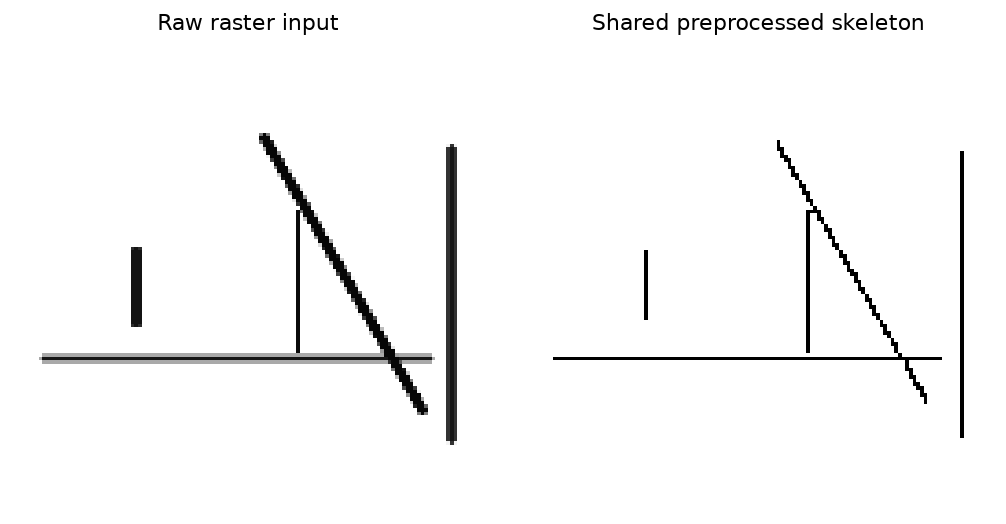

In [8]:
# Shared preprocessing stage for all raster images.
# This is now the only place where skeletonization is applied before comparison.

PREPROCESS_CONFIG = {
    "threshold": 0.5,
    "apply_skeletonization": True,
}


def skeleton_mask_to_raster_image(skeleton):
    """Convert a binary stroke mask into the notebook's raster format: black line on white background."""
    skeleton = (skeleton > 0).astype(np.uint8)
    return np.where(skeleton == 1, 0.0, 1.0).astype(np.float32)


def preprocess_raster_image(image, config=PREPROCESS_CONFIG):
    """Threshold a raster and reduce it to a single-pixel skeleton.

    Input image convention: 0 = black/stroke, 1 = white/background.
    Output image convention: same as input, but with a one-pixel stroke.
    """
    raw_stroke = (image <= float(config["threshold"])).astype(np.uint8)

    if config.get("apply_skeletonization", True):
        processed_stroke = skeletonize_zhang_suen(raw_stroke)
    else:
        processed_stroke = raw_stroke.copy()

    processed_image = skeleton_mask_to_raster_image(processed_stroke)
    debug = {
        "raw_stroke": raw_stroke,
        "skeleton": processed_stroke,
        "raw_stroke_pixels": int(raw_stroke.sum()),
        "processed_stroke_pixels": int(processed_stroke.sum()),
        "apply_skeletonization": bool(config.get("apply_skeletonization", True)),
    }
    return processed_image, debug


def preprocess_raster_dataset(images, config=PREPROCESS_CONFIG):
    processed_images = []
    debug_rows = []
    for image in images:
        processed_image, debug = preprocess_raster_image(image, config=config)
        processed_images.append(processed_image)
        debug_rows.append(debug)
    return np.stack(processed_images).astype(np.float32), debug_rows


train_images_preprocessed, train_preprocess_debug = preprocess_raster_dataset(train_images)
test_images_preprocessed, test_preprocess_debug = preprocess_raster_dataset(test_images)

print('Shared raster preprocessing complete:')
print({
    'train_images_preprocessed': train_images_preprocessed.shape,
    'test_images_preprocessed': test_images_preprocessed.shape,
    'threshold': PREPROCESS_CONFIG['threshold'],
    'apply_skeletonization': PREPROCESS_CONFIG['apply_skeletonization'],
})
print('\nFirst test image stroke pixels:')
print({
    'before_skeletonization': test_preprocess_debug[0]['raw_stroke_pixels'],
    'after_skeletonization': test_preprocess_debug[0]['processed_stroke_pixels'],
})

fig, ax = plt.subplots(1, 2, figsize=(8, 4), dpi=130)
ax[0].imshow(test_images[0], cmap='gray', vmin=0, vmax=1, interpolation='nearest')
ax[0].set_title('Raw raster input')
ax[0].axis('off')
ax[1].imshow(test_images_preprocessed[0], cmap='gray', vmin=0, vmax=1, interpolation='nearest')
ax[1].set_title('Shared preprocessed skeleton')
ax[1].axis('off')
plt.tight_layout()
plt.show()


## Classic vectorisation methods

These are all non-ML methods. They all receive `test_images_preprocessed[idx]`, meaning the thresholding and skeletonisation stage is identical for every method.

The methods deliberately represent different classic approaches rather than tuned variants of one algorithm:

- Hough Transform: global accumulator line voting.
- Contour-based fitting: connected-component / contour approximation by fitted line segments.
- Thinning / skeletonisation: graph tracing on the shared one-pixel skeleton.
- Run-graph based vectorisation: trace degree-2 pixel runs between graph nodes.
- Sparse-pixel RANSAC: random sparse pixel line fitting with inlier removal.
- Mesh-pattern local vectorisation: local cell-wise vector fitting, followed by merging.


In [9]:
# Classic vectorisation method implementations.
# Every function below assumes the input image has already gone through preprocess_raster_image().
# Input convention: 0 = stroke, 1 = background.

CLASSIC_VECTOR_CONFIG = {
    "hough": {
        "angle_step_deg": 1,
        "rho_step_px": 1.0,
        "line_distance_tol_px": 1.25,
        "min_support_pixels": 7,
        "max_lines": MAX_VECTORS * 2,
        "theta_nms_deg": 4,
        "rho_nms_px": 4,
        "merge_angle_tol_deg": 5,
        "merge_endpoint_tol_px": 4,
    },
    "contour": {
        "min_component_pixels": 4,
        "max_fit_error_px": 1.8,
        "max_recursive_splits": 3,
        "merge_angle_tol_deg": 7,
        "merge_endpoint_tol_px": 5,
    },
    "run_graph": {
        "merge_angle_tol_deg": 6,
        "merge_endpoint_tol_px": 4,
    },
    "ransac": {
        "iterations_per_line": 350,
        "distance_tol_px": 1.25,
        "min_inliers": 7,
        "max_lines": MAX_VECTORS * 2,
        "merge_angle_tol_deg": 6,
        "merge_endpoint_tol_px": 5,
    },
    "mesh": {
        "cell_size_px": 16,
        "stride_px": 12,
        "min_cell_pixels": 4,
        "max_local_fit_error_px": 2.0,
        "merge_angle_tol_deg": 8,
        "merge_endpoint_tol_px": 7,
    },
}


def stroke_points_xy_from_image(image):
    stroke = threshold_stroke(image)
    ys, xs = np.where(stroke == 1)
    points_xy = np.column_stack([xs, ys]).astype(np.float32)
    return stroke, points_xy


def clip_line_to_image(line, img_size=IMG_SIZE):
    x0, y0, x1, y1 = map(float, line)
    return (
        float(np.clip(x0, 0, img_size - 1)),
        float(np.clip(y0, 0, img_size - 1)),
        float(np.clip(x1, 0, img_size - 1)),
        float(np.clip(y1, 0, img_size - 1)),
    )


def line_from_xy_points(points_xy):
    """Fit one finite line segment to x/y points using PCA."""
    points_xy = np.asarray(points_xy, dtype=np.float32)
    if len(points_xy) < 2:
        return None

    centre = points_xy.mean(axis=0)
    centred = points_xy - centre
    if np.allclose(centred, 0):
        return None

    _, _, vh = np.linalg.svd(centred, full_matrices=False)
    direction = vh[0].astype(np.float32)
    norm = float(np.linalg.norm(direction))
    if norm <= 1e-9:
        return None
    direction = direction / norm

    t = centred @ direction
    p0 = centre + direction * float(t.min())
    p1 = centre + direction * float(t.max())
    return clip_line_to_image((p0[0], p0[1], p1[0], p1[1]))


def point_line_distances_xy(points_xy, line):
    x0, y0, x1, y1 = map(float, line)
    px = points_xy[:, 0]
    py = points_xy[:, 1]
    vx = x1 - x0
    vy = y1 - y0
    denom = math.hypot(vx, vy)
    if denom <= 1e-9:
        return np.hypot(px - x0, py - y0)
    return np.abs(vy * px - vx * py + x1 * y0 - y1 * x0) / denom


def line_fit_error_xy(points_xy, line):
    if line is None or len(points_xy) == 0:
        return float('inf'), float('inf')
    distances = point_line_distances_xy(points_xy, line)
    return float(np.mean(distances)), float(np.max(distances))


def cleanup_classic_vectors(vectors, angle_tol_deg=6, endpoint_tol_px=5):
    cleaned = []
    for vector in vectors:
        if vector is None:
            continue
        vector = clip_line_to_image(vector)
        if line_length(vector) >= MIN_VECTOR_LENGTH:
            cleaned.append(vector)

    if not cleaned:
        return []

    return merge_collinear_vectors_fast(
        cleaned,
        angle_tol_deg=float(angle_tol_deg),
        endpoint_tol=float(endpoint_tol_px),
    )


def stable_rng_for_stroke(stroke, salt=0):
    flat_indices = np.flatnonzero(stroke.ravel())
    seed = int((flat_indices.sum() + 1009 * len(flat_indices) + salt) % (2**32 - 1))
    return np.random.default_rng(seed)


# -------------------------------------------------------------------
# 1. Hough Transform
# -------------------------------------------------------------------
def reconstruct_vectors_hough_transform(image, config=None):
    if config is None:
        config = CLASSIC_VECTOR_CONFIG["hough"]

    stroke, points_xy = stroke_points_xy_from_image(image)
    if len(points_xy) < 2:
        return [], {
            "method": "hough_transform_on_shared_skeleton",
            "stroke": stroke,
            "internal_skeletonization_applied": False,
        }

    angle_step = int(config["angle_step_deg"])
    theta_degs = np.arange(0, 180, angle_step, dtype=np.float32)
    theta = np.deg2rad(theta_degs)
    cos_t = np.cos(theta)
    sin_t = np.sin(theta)

    rho_step = float(config["rho_step_px"])
    rho_max = math.ceil(math.hypot(*stroke.shape))
    n_rho = int(2 * rho_max / rho_step) + 1
    accumulator = np.zeros((len(theta), n_rho), dtype=np.int32)

    xs = points_xy[:, 0]
    ys = points_xy[:, 1]
    for ti, (c, s) in enumerate(zip(cos_t, sin_t)):
        rho_bins = np.rint((xs * c + ys * s + rho_max) / rho_step).astype(np.int32)
        valid = (rho_bins >= 0) & (rho_bins < n_rho)
        accumulator[ti] = np.bincount(rho_bins[valid], minlength=n_rho)

    min_votes = int(config["min_support_pixels"])
    peak_indices = np.argwhere(accumulator >= min_votes)
    candidates = []
    for ti, ri in peak_indices:
        candidates.append((int(accumulator[ti, ri]), int(ti), int(ri)))
    candidates.sort(reverse=True, key=lambda row: row[0])

    selected_peaks = []
    used_points = np.zeros(len(points_xy), dtype=bool)
    vectors = []

    def theta_close(a, b):
        d = abs(float(a) - float(b)) % 180.0
        return min(d, 180.0 - d)

    for votes, ti, ri in candidates:
        if len(vectors) >= int(config["max_lines"]):
            break

        theta_deg = float(theta_degs[ti])
        rho = float(ri * rho_step - rho_max)

        # Non-maximum suppression in Hough parameter space.
        suppressed = False
        for prev_theta, prev_rho in selected_peaks:
            if (
                theta_close(theta_deg, prev_theta) <= float(config["theta_nms_deg"])
                and abs(rho - prev_rho) <= float(config["rho_nms_px"])
            ):
                suppressed = True
                break
        if suppressed:
            continue

        normal = np.array([math.cos(math.radians(theta_deg)), math.sin(math.radians(theta_deg))], dtype=np.float32)
        distances = np.abs(points_xy @ normal - rho)
        inliers = (distances <= float(config["line_distance_tol_px"])) & (~used_points)

        if int(inliers.sum()) < min_votes:
            continue

        line = line_from_xy_points(points_xy[inliers])
        if line is None or line_length(line) < MIN_VECTOR_LENGTH:
            continue

        vectors.append(line)
        used_points[inliers] = True
        selected_peaks.append((theta_deg, rho))

    vectors = cleanup_classic_vectors(
        vectors,
        angle_tol_deg=config["merge_angle_tol_deg"],
        endpoint_tol_px=config["merge_endpoint_tol_px"],
    )

    debug = {
        "method": "hough_transform_on_shared_skeleton",
        "stroke": stroke,
        "hough_accumulator": accumulator,
        "selected_peaks": selected_peaks,
        "candidate_peak_count": len(candidates),
        "internal_skeletonization_applied": False,
        "config": dict(config),
    }
    return vectors, debug


# -------------------------------------------------------------------
# 2. Contour-based fitting
# -------------------------------------------------------------------
def recursive_contour_fit(points_xy, config, depth=0):
    line = line_from_xy_points(points_xy)
    if line is None:
        return []

    mean_error, max_error = line_fit_error_xy(points_xy, line)
    if (
        depth >= int(config["max_recursive_splits"])
        or len(points_xy) < 2 * int(config["min_component_pixels"])
        or max_error <= float(config["max_fit_error_px"])
    ):
        return [line]

    # Split the component along its strongest PCA axis and fit each side.
    centre = points_xy.mean(axis=0)
    centred = points_xy - centre
    _, _, vh = np.linalg.svd(centred, full_matrices=False)
    principal = vh[0]
    t = centred @ principal
    split_at = float(np.median(t))
    left = points_xy[t <= split_at]
    right = points_xy[t > split_at]

    min_pixels = int(config["min_component_pixels"])
    if len(left) < min_pixels or len(right) < min_pixels:
        return [line]

    return (
        recursive_contour_fit(left, config, depth + 1)
        + recursive_contour_fit(right, config, depth + 1)
    )


def reconstruct_vectors_contour_fitting(image, config=None):
    if config is None:
        config = CLASSIC_VECTOR_CONFIG["contour"]

    stroke = threshold_stroke(image)
    vectors = []
    components = connected_components(stroke)

    for comp in components:
        if len(comp) < int(config["min_component_pixels"]):
            continue
        points_xy = np.array([(x, y) for y, x in comp], dtype=np.float32)
        vectors.extend(recursive_contour_fit(points_xy, config=config, depth=0))

    vectors = cleanup_classic_vectors(
        vectors,
        angle_tol_deg=config["merge_angle_tol_deg"],
        endpoint_tol_px=config["merge_endpoint_tol_px"],
    )

    debug = {
        "method": "contour_based_fitting_on_shared_skeleton",
        "stroke": stroke,
        "components": components,
        "component_count": len(components),
        "internal_skeletonization_applied": False,
        "config": dict(config),
    }
    return vectors, debug


# -------------------------------------------------------------------
# 3. Thinning / skeletonisation graph tracing
# -------------------------------------------------------------------
def reconstruct_vectors_thinning_skeletonisation(image):
    vectors, debug = reconstruct_vectors_with_skeleton_junction_fix(image, config=SKELETON_GRAPH_CONFIG)
    debug = dict(debug)
    debug["method"] = "thinning_skeletonisation_graph_tracing_on_shared_skeleton"
    debug["internal_skeletonization_applied"] = False
    return vectors, debug


# -------------------------------------------------------------------
# 4. Run-graph based vectorisation
# -------------------------------------------------------------------
def make_degree_node_map(stroke):
    degree = np.zeros_like(stroke, dtype=np.uint8)
    ys, xs = np.where(stroke == 1)
    for y, x in zip(ys, xs):
        degree[y, x] = len(skeleton_neighbours(stroke, y, x))

    # A run node is anything that is not a simple degree-2 continuation pixel.
    node_seed = ((stroke == 1) & (degree != 2)).astype(np.uint8)
    node_map = -np.ones_like(stroke, dtype=np.int32)
    nodes = []

    for comp in connected_components(node_seed):
        if not comp:
            continue
        ys = np.array([p[0] for p in comp], dtype=np.float32)
        xs = np.array([p[1] for p in comp], dtype=np.float32)
        comp_degrees = [int(degree[y, x]) for y, x in comp]
        if max(comp_degrees) >= 3:
            node_type = "junction"
        elif max(comp_degrees) == 1:
            node_type = "endpoint"
        else:
            node_type = "isolated_or_corner"

        node_id = len(nodes)
        nodes.append({
            "type": node_type,
            "x": float(xs.mean()),
            "y": float(ys.mean()),
            "pixels": comp,
            "degrees": comp_degrees,
        })
        for y, x in comp:
            node_map[y, x] = node_id

    return degree, node_seed, nodes, node_map


def trace_run_graph_vectors(stroke, nodes, node_map):
    h, w = stroke.shape
    visited_edges = set()
    vectors = []
    paths = []

    def edge_key(a, b):
        return tuple(sorted((tuple(a), tuple(b))))

    for start_node_id, node in enumerate(nodes):
        for sy, sx in node["pixels"]:
            for ny, nx in skeleton_neighbours(stroke, sy, sx):
                if node_map[ny, nx] == start_node_id:
                    continue
                if edge_key((sy, sx), (ny, nx)) in visited_edges:
                    continue

                path = [(sy, sx), (ny, nx)]
                visited_edges.add(edge_key((sy, sx), (ny, nx)))
                prev = (sy, sx)
                cur = (ny, nx)
                end_node_id = int(node_map[cur])
                steps = 0

                while end_node_id < 0 and steps < h * w:
                    candidates = [p for p in skeleton_neighbours(stroke, *cur) if p != prev]
                    if not candidates:
                        break
                    node_candidates = [p for p in candidates if node_map[p] >= 0]
                    if node_candidates:
                        nxt = node_candidates[0]
                    else:
                        unvisited = [p for p in candidates if edge_key(cur, p) not in visited_edges]
                        if not unvisited:
                            break
                        nxt = min(unvisited, key=lambda p: step_score(prev, cur, p))

                    visited_edges.add(edge_key(cur, nxt))
                    prev, cur = cur, nxt
                    path.append(cur)
                    end_node_id = int(node_map[cur])
                    steps += 1

                if len(path) >= 2:
                    line = make_branch_line(path, nodes, start_node_id, end_node_id)
                    if line_length(line) >= MIN_VECTOR_LENGTH:
                        vectors.append(line)
                        paths.append(path)

    # Components without nodes, such as loops, get one fallback fit.
    if not vectors:
        for comp in connected_components(stroke):
            if len(comp) >= 2:
                line = fit_line_to_path(comp)
                if line is not None:
                    vectors.append(line)
                    paths.append(comp)

    return vectors, paths


def reconstruct_vectors_run_graph(image, config=None):
    if config is None:
        config = CLASSIC_VECTOR_CONFIG["run_graph"]

    stroke = threshold_stroke(image)
    degree, node_seed, nodes, node_map = make_degree_node_map(stroke)
    vectors, paths = trace_run_graph_vectors(stroke, nodes, node_map)
    vectors = cleanup_classic_vectors(
        vectors,
        angle_tol_deg=config["merge_angle_tol_deg"],
        endpoint_tol_px=config["merge_endpoint_tol_px"],
    )

    debug = {
        "method": "run_graph_vectorisation_on_shared_skeleton",
        "stroke": stroke,
        "degree": degree,
        "node_seed_mask": node_seed,
        "nodes": nodes,
        "node_map": node_map,
        "paths": paths,
        "internal_skeletonization_applied": False,
        "config": dict(config),
    }
    return vectors, debug


# -------------------------------------------------------------------
# 5. Sparse-pixel RANSAC vectorisation
# -------------------------------------------------------------------
def reconstruct_vectors_sparse_pixel_ransac(image, config=None):
    if config is None:
        config = CLASSIC_VECTOR_CONFIG["ransac"]

    stroke, points_xy = stroke_points_xy_from_image(image)
    rng = stable_rng_for_stroke(stroke, salt=12345)

    remaining = points_xy.copy()
    vectors = []
    ransac_rows = []

    for line_idx in range(int(config["max_lines"])):
        if len(remaining) < int(config["min_inliers"]):
            break

        best_mask = None
        best_count = 0
        best_line = None

        for _ in range(int(config["iterations_per_line"])):
            if len(remaining) < 2:
                break
            pair_idx = rng.choice(len(remaining), size=2, replace=False)
            p0, p1 = remaining[pair_idx]
            candidate = (p0[0], p0[1], p1[0], p1[1])
            if line_length(candidate) < MIN_VECTOR_LENGTH:
                continue

            distances = point_line_distances_xy(remaining, candidate)
            mask = distances <= float(config["distance_tol_px"])
            count = int(mask.sum())

            if count > best_count:
                inlier_line = line_from_xy_points(remaining[mask])
                if inlier_line is not None:
                    best_count = count
                    best_mask = mask
                    best_line = inlier_line

        if best_mask is None or best_count < int(config["min_inliers"]):
            break

        vectors.append(best_line)
        ransac_rows.append({"line_idx": line_idx, "inliers": best_count})
        remaining = remaining[~best_mask]

    vectors = cleanup_classic_vectors(
        vectors,
        angle_tol_deg=config["merge_angle_tol_deg"],
        endpoint_tol_px=config["merge_endpoint_tol_px"],
    )

    debug = {
        "method": "sparse_pixel_ransac_vectorisation_on_shared_skeleton",
        "stroke": stroke,
        "ransac_rows": ransac_rows,
        "remaining_points": int(len(remaining)),
        "internal_skeletonization_applied": False,
        "config": dict(config),
    }
    return vectors, debug


# -------------------------------------------------------------------
# 6. Mesh-pattern local vectorisation
# -------------------------------------------------------------------
def reconstruct_vectors_mesh_pattern_local(image, config=None):
    if config is None:
        config = CLASSIC_VECTOR_CONFIG["mesh"]

    stroke = threshold_stroke(image)
    h, w = stroke.shape
    cell = int(config["cell_size_px"])
    stride = int(config["stride_px"])
    vectors = []
    local_rows = []

    for y0 in range(0, h, stride):
        for x0 in range(0, w, stride):
            y1 = min(h, y0 + cell)
            x1 = min(w, x0 + cell)
            tile = stroke[y0:y1, x0:x1]
            ys, xs = np.where(tile == 1)
            if len(xs) < int(config["min_cell_pixels"]):
                continue

            points_xy = np.column_stack([xs + x0, ys + y0]).astype(np.float32)
            line = line_from_xy_points(points_xy)
            if line is None:
                continue
            mean_error, max_error = line_fit_error_xy(points_xy, line)
            if max_error > float(config["max_local_fit_error_px"]):
                continue
            if line_length(line) < MIN_VECTOR_LENGTH:
                continue

            vectors.append(line)
            local_rows.append({
                "x0": x0,
                "y0": y0,
                "points": int(len(points_xy)),
                "mean_error": mean_error,
                "max_error": max_error,
            })

    vectors = cleanup_classic_vectors(
        vectors,
        angle_tol_deg=config["merge_angle_tol_deg"],
        endpoint_tol_px=config["merge_endpoint_tol_px"],
    )

    debug = {
        "method": "mesh_pattern_local_vectorisation_on_shared_skeleton",
        "stroke": stroke,
        "local_rows": local_rows,
        "candidate_local_segments": len(local_rows),
        "internal_skeletonization_applied": False,
        "config": dict(config),
    }
    return vectors, debug


## Method map

This cell defines exactly which methods are compared. Add, remove, or reorder methods here.


In [10]:
METHODS_TO_COMPARE = {
    "baseline_on_shared_skeleton": lambda image: reconstruct_vectors_from_image(image, method="baseline"),
    "hough_transform_on_shared_skeleton": reconstruct_vectors_hough_transform,
    "contour_based_fitting_on_shared_skeleton": reconstruct_vectors_contour_fitting,
    "thinning_skeletonisation_graph_tracing_on_shared_skeleton": reconstruct_vectors_thinning_skeletonisation,
    "run_graph_vectorisation_on_shared_skeleton": reconstruct_vectors_run_graph,
    "sparse_pixel_ransac_vectorisation_on_shared_skeleton": reconstruct_vectors_sparse_pixel_ransac,
    "mesh_pattern_local_vectorisation_on_shared_skeleton": reconstruct_vectors_mesh_pattern_local,
}

METHOD_DISPLAY_NAMES = {
    "baseline_on_shared_skeleton": "Baseline",
    "hough_transform_on_shared_skeleton": "Hough Transform",
    "contour_based_fitting_on_shared_skeleton": "Contour-based fitting",
    "thinning_skeletonisation_graph_tracing_on_shared_skeleton": "Thinning / skeletonisation",
    "run_graph_vectorisation_on_shared_skeleton": "Run-graph vectorisation",
    "sparse_pixel_ransac_vectorisation_on_shared_skeleton": "Sparse-pixel RANSAC",
    "mesh_pattern_local_vectorisation_on_shared_skeleton": "Mesh-pattern local",
}

pd.DataFrame({
    "method_key": list(METHODS_TO_COMPARE.keys()),
    "display_name": [METHOD_DISPLAY_NAMES[k] for k in METHODS_TO_COMPARE.keys()],
})


,method_key,display_name
0,baseline_on_shared_skeleton,Baseline
1,hough_transform_on_shared_skeleton,Hough Transform
2,contour_based_fitting_on_shared_skeleton,Contour-based fitting
3,thinning_skeletonisation_graph_tracing_on_shar...,Thinning / skeletonisation
4,run_graph_vectorisation_on_shared_skeleton,Run-graph vectorisation
5,sparse_pixel_ransac_vectorisation_on_shared_sk...,Sparse-pixel RANSAC
6,mesh_pattern_local_vectorisation_on_shared_ske...,Mesh-pattern local


## Original engineering metrics, reused

In [11]:
import pandas as pd
import numpy as np

METHODS = list(METHODS_TO_COMPARE.keys()) if "METHODS_TO_COMPARE" in globals() else []


def raster_metrics(true_raster, pred_raster):
    """Pixel-overlap metrics are kept as a secondary check only."""
    true = true_raster < 0.5
    pred = pred_raster < 0.5

    tp = np.logical_and(true, pred).sum()
    fp = np.logical_and(~true, pred).sum()
    fn = np.logical_and(true, ~pred).sum()
    tn = np.logical_and(~true, ~pred).sum()

    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    iou = tp / (tp + fp + fn + 1e-9)
    accuracy = (tp + tn) / (tp + fp + fn + tn + 1e-9)

    return precision, recall, f1, iou, accuracy


def vector_length_px(v):
    x0, y0, x1, y1 = v
    return math.hypot(x1 - x0, y1 - y0)


def vector_angle_deg(v, config=GEOMETRY_CONFIG):
    """Return an undirected snapped angle in degrees: 0 and 180 are equivalent."""
    x0, y0, x1, y1 = v
    angle = math.degrees(math.atan2(y1 - y0, x1 - x0)) % 180
    return snap_angle_deg(angle, config["angle_unit_deg"])


def angle_distance_deg(a, b):
    """Smallest distance between two undirected line angles."""
    d = abs(a - b) % 180
    return min(d, 180 - d)


def angle_family_importance(angle_deg, config=GEOMETRY_CONFIG):
    """Return a programmable importance weight for an angle.

    Example: 90-degree family angles are more important than arbitrary 1-degree angles.
    This does not change the geometry; it changes how strongly the metric cares about mistakes.
    """
    best = min(config["angle_unit_weights"].values())
    for unit, weight in config["angle_unit_weights"].items():
        if unit <= 1:
            continue
        nearest = round(angle_deg / unit) * unit
        err = angle_distance_deg(angle_deg, nearest)
        if err <= config["angle_unit_deg"] / 2 + 1e-9:
            best = max(best, weight)
    return best


def vector_count_score(true_vectors, pred_vectors):
    denom = max(len(true_vectors), len(pred_vectors), 1)
    return max(0.0, 1.0 - abs(len(true_vectors) - len(pred_vectors)) / denom)


def total_length_score(true_vectors, pred_vectors):
    true_total = sum(snap_length_px(vector_length_px(v)) for v in true_vectors)
    pred_total = sum(snap_length_px(vector_length_px(v)) for v in pred_vectors)
    denom = max(true_total, pred_total, 1e-9)
    return max(0.0, 1.0 - abs(true_total - pred_total) / denom)


def greedy_line_geometry_score(true_vectors, pred_vectors, config=GEOMETRY_CONFIG):
    """Compare lines by length and angle, not by absolute endpoint location.

    This is the key metric for your goal: a 10x10 square translated slightly should still score well
    because its line lengths and line angles are right.
    """
    if len(true_vectors) == 0 and len(pred_vectors) == 0:
        return 1.0
    if len(true_vectors) == 0 or len(pred_vectors) == 0:
        return 0.0

    candidates = []
    for i, gt in enumerate(true_vectors):
        gt_len = snap_length_px(vector_length_px(gt), config["length_unit_px"])
        gt_ang = vector_angle_deg(gt, config)
        importance = angle_family_importance(gt_ang, config)

        for j, pred in enumerate(pred_vectors):
            pred_len = snap_length_px(vector_length_px(pred), config["length_unit_px"])
            pred_ang = vector_angle_deg(pred, config)

            angle_err = angle_distance_deg(gt_ang, pred_ang)
            length_err = abs(gt_len - pred_len)

            angle_part = max(0.0, 1.0 - angle_err / config["line_angle_tolerance_deg"])
            length_tol = max(config["length_unit_px"], config["length_tolerance_ratio"] * max(gt_len, 1.0))
            length_part = max(0.0, 1.0 - length_err / length_tol)

            pair_score = 0.65 * angle_part + 0.35 * length_part
            candidates.append((pair_score, importance, i, j))

    candidates.sort(reverse=True, key=lambda x: x[0])
    used_true = set()
    used_pred = set()
    weighted_score = 0.0

    for pair_score, importance, i, j in candidates:
        if i in used_true or j in used_pred:
            continue
        used_true.add(i)
        used_pred.add(j)
        weighted_score += pair_score * importance

    total_importance = sum(angle_family_importance(vector_angle_deg(v, config), config) for v in true_vectors)
    return weighted_score / max(total_importance, 1e-9)


def junction_angles_deg(vectors, config=GEOMETRY_CONFIG):
    """Return the acute angles at all places where two predicted/true segments meet or cross.

    This ignores the absolute location of the junction. It cares that the drawing contains the right
    kind of junctions, such as 90-degree corners in a square.
    """
    angles = []
    for i in range(len(vectors)):
        for j in range(i + 1, len(vectors)):
            p = segment_intersection(vectors[i], vectors[j])
            if p is None:
                continue
            a = vector_angle_deg(vectors[i], config)
            b = vector_angle_deg(vectors[j], config)
            d = angle_distance_deg(a, b)
            acute = min(d, 180 - d)
            if acute > 1e-6:
                angles.append(snap_angle_deg(acute, config["angle_unit_deg"]))
    return angles


def angle_list_score(true_angles, pred_angles, tolerance_deg):
    if len(true_angles) == 0 and len(pred_angles) == 0:
        return 1.0
    if len(true_angles) == 0 or len(pred_angles) == 0:
        return 0.0

    candidates = []
    for i, a in enumerate(true_angles):
        for j, b in enumerate(pred_angles):
            err = abs(a - b)
            score = max(0.0, 1.0 - err / tolerance_deg)
            candidates.append((score, i, j))

    candidates.sort(reverse=True, key=lambda x: x[0])
    used_true = set()
    used_pred = set()
    total = 0.0

    for score, i, j in candidates:
        if i in used_true or j in used_pred:
            continue
        used_true.add(i)
        used_pred.add(j)
        total += score

    return total / max(len(true_angles), len(pred_angles), 1)


def engineering_metrics(true_vectors, pred_vectors, config=GEOMETRY_CONFIG):
    line_geometry = greedy_line_geometry_score(true_vectors, pred_vectors, config)
    length_total = total_length_score(true_vectors, pred_vectors)
    count = vector_count_score(true_vectors, pred_vectors)

    true_junction_angles = junction_angles_deg(true_vectors, config)
    pred_junction_angles = junction_angles_deg(pred_vectors, config)
    junction_angles = angle_list_score(
        true_junction_angles,
        pred_junction_angles,
        config["junction_angle_tolerance_deg"],
    )

    w = config["score_weights"]
    engineering_score = (
        w["line_geometry"] * line_geometry
        + w["total_length"] * length_total
        + w["junction_angles"] * junction_angles
        + w["vector_count"] * count
    )

    return {
        "engineering_score": engineering_score,
        "line_geometry_score": line_geometry,
        "total_length_score": length_total,
        "junction_angle_score": junction_angles,
        "vector_count_score": count,
        "true_junctions": len(true_junction_angles),
        "pred_junctions": len(pred_junction_angles),
    }

## Compare baseline against classic vectorisation methods

All methods are tested on `test_images_preprocessed`. Pixel-overlap metrics are measured against the shared preprocessed skeleton raster. Engineering metrics are measured against the original target vectors, so total length, line angle, junction-angle structure, and vector count matter more than exact absolute coordinate matching.


In [12]:
# Baseline and classic vectorisation comparison.
# IMPORTANT: every comparison method receives test_images_preprocessed[idx].

EXPORT_DIR = Path('classic-learning')
EXPORT_DIR.mkdir(parents=True, exist_ok=True)


def binary_confusion_counts(target_raster, pred_raster, threshold=0.5):
    """
    Binary confusion matrix for raster vectorisation.

    Assumes the notebook raster convention:
    - 0 = stroke / line pixel
    - 1 = background
    """
    target = np.asarray(target_raster) < threshold
    pred = np.asarray(pred_raster) < threshold

    tp = int(np.logical_and(target, pred).sum())
    fp = int(np.logical_and(~target, pred).sum())
    fn = int(np.logical_and(target, ~pred).sum())
    tn = int(np.logical_and(~target, ~pred).sum())

    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    accuracy = (tp + tn) / (tp + fp + fn + tn + 1e-9)
    iou = tp / (tp + fp + fn + 1e-9)

    return {
        'tp': tp,
        'fp': fp,
        'fn': fn,
        'tn': tn,
        'precision_from_matrix': precision,
        'recall_from_matrix': recall,
        'f1_from_matrix': f1,
        'accuracy_from_matrix': accuracy,
        'iou_from_matrix': iou,
    }


def confusion_matrix_from_counts(row):
    """
    Standard binary confusion matrix layout:

                    Pred background   Pred stroke
    True background       TN               FP
    True stroke           FN               TP
    """
    return np.array([
        [row['tn'], row['fp']],
        [row['fn'], row['tp']],
    ])


# Better table display in Jupyter.
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 180)
pd.set_option('display.float_format', '{:.4f}'.format)

comparison_outputs = {}
comparison_rows = []

for idx, (raw_image, preprocessed_image, true_vectors) in enumerate(
    zip(test_images, test_images_preprocessed, test_vectors)
):
    comparison_outputs[idx] = {}

    for method_name, method_fn in METHODS_TO_COMPARE.items():
        pred_vectors, debug = method_fn(preprocessed_image)
        debug = dict(debug)
        debug['preprocessing'] = test_preprocess_debug[idx]

        comparison_outputs[idx][method_name] = {
            'vectors': pred_vectors,
            'debug': debug,
        }

        pred_raster = rasterise_vectors(pred_vectors, IMG_SIZE)

        # Pixel metrics use the shared skeleton raster as the target, not the original thick raster.
        precision, recall, f1, iou, pixel_accuracy = raster_metrics(preprocessed_image, pred_raster)
        confusion = binary_confusion_counts(preprocessed_image, pred_raster)

        geom = engineering_metrics(true_vectors, pred_vectors, GEOMETRY_CONFIG)
        class_counts = debug.get('classification_counts', {})

        comparison_rows.append({
            'method': method_name,
            'method_display': METHOD_DISPLAY_NAMES.get(method_name, method_name),
            'sample': idx,

            'true_vectors': len(true_vectors),
            'pred_vectors': len(pred_vectors),
            'vector_count_error': abs(len(true_vectors) - len(pred_vectors)),

            **geom,

            'pixel_precision_on_skeleton': precision,
            'pixel_recall_on_skeleton': recall,
            'pixel_f1_on_skeleton': f1,
            'pixel_iou_on_skeleton': iou,
            'pixel_accuracy_on_skeleton': pixel_accuracy,

            'tp': confusion['tp'],
            'fp': confusion['fp'],
            'fn': confusion['fn'],
            'tn': confusion['tn'],

            'precision_from_matrix': confusion['precision_from_matrix'],
            'recall_from_matrix': confusion['recall_from_matrix'],
            'f1_from_matrix': confusion['f1_from_matrix'],
            'accuracy_from_matrix': confusion['accuracy_from_matrix'],
            'iou_from_matrix': confusion['iou_from_matrix'],

            'raw_stroke_pixels': test_preprocess_debug[idx]['raw_stroke_pixels'],
            'skeleton_stroke_pixels': test_preprocess_debug[idx]['processed_stroke_pixels'],

            'graph_node_clusters': len(debug.get('nodes', [])),
            'traced_paths': len(debug.get('paths', [])),
            'candidate_peak_count': debug.get('candidate_peak_count', np.nan),
            'component_count': debug.get('component_count', np.nan),
            'candidate_local_segments': debug.get('candidate_local_segments', np.nan),
            'remaining_ransac_points': debug.get('remaining_points', np.nan),

            'classified_line_pixels': class_counts.get('line', np.nan),
            'classified_endpoint_pixels': class_counts.get('endpoint', np.nan),
            'classified_corner_pixels': class_counts.get('corner', np.nan),
            'classified_t_junction_pixels': class_counts.get('t_junction', np.nan),
            'classified_x_junction_pixels': class_counts.get('x_junction', np.nan),

            'internal_skeletonization_applied': debug.get('internal_skeletonization_applied', None),
        })


comparison_df = pd.DataFrame(comparison_rows)

summary_df = (
    comparison_df
    .groupby('method_display')
    .mean(numeric_only=True)
    .sort_values('engineering_score', ascending=False)
    .round(4)
)

# Confusion matrix totals.
confusion_summary_df = (
    comparison_df
    .groupby('method_display')[['tp', 'fp', 'fn', 'tn']]
    .sum()
)

# F1 / accuracy matrix.
f1_accuracy_matrix_df = comparison_df.groupby('method_display').agg(
    tp=('tp', 'sum'),
    fp=('fp', 'sum'),
    fn=('fn', 'sum'),
    tn=('tn', 'sum'),

    mean_precision=('precision_from_matrix', 'mean'),
    mean_recall=('recall_from_matrix', 'mean'),
    mean_f1=('f1_from_matrix', 'mean'),
    mean_accuracy=('accuracy_from_matrix', 'mean'),
    mean_iou=('iou_from_matrix', 'mean'),

    mean_engineering_score=('engineering_score', 'mean'),
    mean_line_geometry_score=('line_geometry_score', 'mean'),
    mean_total_length_score=('total_length_score', 'mean'),
    mean_junction_angle_score=('junction_angle_score', 'mean'),
    mean_vector_count_error=('vector_count_error', 'mean'),
)

# Recalculate global metrics from total TP/FP/FN/TN.
f1_accuracy_matrix_df['global_precision'] = (
    f1_accuracy_matrix_df['tp'] /
    (f1_accuracy_matrix_df['tp'] + f1_accuracy_matrix_df['fp'] + 1e-9)
)

f1_accuracy_matrix_df['global_recall'] = (
    f1_accuracy_matrix_df['tp'] /
    (f1_accuracy_matrix_df['tp'] + f1_accuracy_matrix_df['fn'] + 1e-9)
)

f1_accuracy_matrix_df['global_f1'] = (
    2 * f1_accuracy_matrix_df['global_precision'] * f1_accuracy_matrix_df['global_recall'] /
    (f1_accuracy_matrix_df['global_precision'] + f1_accuracy_matrix_df['global_recall'] + 1e-9)
)

f1_accuracy_matrix_df['global_accuracy'] = (
    (f1_accuracy_matrix_df['tp'] + f1_accuracy_matrix_df['tn']) /
    (
        f1_accuracy_matrix_df['tp'] +
        f1_accuracy_matrix_df['fp'] +
        f1_accuracy_matrix_df['fn'] +
        f1_accuracy_matrix_df['tn'] +
        1e-9
    )
)

f1_accuracy_matrix_df['global_iou'] = (
    f1_accuracy_matrix_df['tp'] /
    (
        f1_accuracy_matrix_df['tp'] +
        f1_accuracy_matrix_df['fp'] +
        f1_accuracy_matrix_df['fn'] +
        1e-9
    )
)

f1_accuracy_matrix_df = f1_accuracy_matrix_df.round(4)

# Cleaner score table with the most important columns first.
score_matrix_df = f1_accuracy_matrix_df[[
    'global_precision',
    'global_recall',
    'global_f1',
    'global_accuracy',
    'global_iou',

    'mean_precision',
    'mean_recall',
    'mean_f1',
    'mean_accuracy',
    'mean_iou',

    'mean_engineering_score',
    'mean_line_geometry_score',
    'mean_total_length_score',
    'mean_junction_angle_score',
    'mean_vector_count_error',

    'tp',
    'fp',
    'fn',
    'tn',
]].sort_values('mean_engineering_score', ascending=False)

# Save outputs.
results_csv = EXPORT_DIR / 'classic_methods_shared_preprocessing_results.csv'
summary_csv = EXPORT_DIR / 'classic_methods_shared_preprocessing_summary.csv'
confusion_csv = EXPORT_DIR / 'classic_methods_confusion_matrix.csv'
f1_accuracy_csv = EXPORT_DIR / 'classic_methods_f1_accuracy_matrix.csv'
score_matrix_csv = EXPORT_DIR / 'classic_methods_score_matrix.csv'

comparison_df.to_csv(results_csv, index=False)
summary_df.to_csv(summary_csv)
confusion_summary_df.to_csv(confusion_csv)
f1_accuracy_matrix_df.to_csv(f1_accuracy_csv)
score_matrix_df.to_csv(score_matrix_csv)

# Display output with comfortable spacing.
display(Markdown("# Baseline vs classic vectorisation methods"))

display(Markdown("## Data / constants"))

constants_df = pd.DataFrame([{
    'IMG_SIZE': IMG_SIZE,
    'MAX_VECTORS': MAX_VECTORS,
    'LINE_WIDTH': LINE_WIDTH,
    'N_TEST': N_TEST,
    'JUNCTION_RADIUS': JUNCTION_RADIUS,
    'MIN_VECTOR_LENGTH': MIN_VECTOR_LENGTH,
    'MAX_MERGE_PASSES': MAX_MERGE_PASSES,
    'EXPORT_DIR': str(EXPORT_DIR),
}])

display(constants_df)


display(Markdown("## Comparison setup"))

setup_df = pd.DataFrame([
    {
        'item': 'comparison_input',
        'value': 'shared preprocessed one-pixel skeleton raster',
    },
    {
        'item': 'preprocessing',
        'value': 'thresholding and Zhang-Suen skeletonisation applied once before every method',
    },
    {
        'item': 'evaluation_target_for_pixel_metrics',
        'value': 'shared preprocessed skeleton raster',
    },
    {
        'item': 'evaluation_target_for_engineering_metrics',
        'value': 'original synthetic vectors: length, angle, junction angle, and vector count',
    },
    {
        'item': 'output_folder',
        'value': str(EXPORT_DIR),
    },
])

display(setup_df)


display(Markdown("## Methods compared"))
display(pd.DataFrame({
    'method_key': list(METHODS_TO_COMPARE.keys()),
    'display_name': [METHOD_DISPLAY_NAMES[k] for k in METHODS_TO_COMPARE.keys()],
}))


display(Markdown("## Classic method config"))
config_rows = []
for family, config in CLASSIC_VECTOR_CONFIG.items():
    row = {'method_family': family}
    row.update(config)
    config_rows.append(row)
display(pd.DataFrame(config_rows))


display(Markdown("## Skeleton graph config"))
display(pd.DataFrame([SKELETON_GRAPH_CONFIG]))


display(Markdown("## Average method comparison"))
display(summary_df)


display(Markdown("## F1 / Accuracy / Engineering Score Matrix"))
display(score_matrix_df)


display(Markdown("## Confusion matrix totals by method"))
display(confusion_summary_df)


display(Markdown("## Individual confusion matrices"))
for method_name, row in confusion_summary_df.iterrows():
    matrix = confusion_matrix_from_counts(row)

    matrix_df = pd.DataFrame(
        matrix,
        index=['true_background', 'true_stroke'],
        columns=['pred_background', 'pred_stroke']
    )

    display(Markdown(f"### {method_name}"))
    display(matrix_df)


display(Markdown("## First few per-sample rows"))
display(comparison_df.head(10))


display(Markdown("## Saved files"))
saved_files_df = pd.DataFrame({
    'file': [
        results_csv,
        summary_csv,
        confusion_csv,
        f1_accuracy_csv,
        score_matrix_csv,
    ]
})

display(saved_files_df)


# Baseline vs classic vectorisation methods

## Data / constants

,IMG_SIZE,MAX_VECTORS,LINE_WIDTH,N_TEST,JUNCTION_RADIUS,MIN_VECTOR_LENGTH,MAX_MERGE_PASSES,EXPORT_DIR
0,128,20,1,25,2,2.0000,2,classic-learning


## Comparison setup

,item,value
0,comparison_input,shared preprocessed one-pixel skeleton raster
1,preprocessing,thresholding and Zhang-Suen skeletonisation ap...
2,evaluation_target_for_pixel_metrics,shared preprocessed skeleton raster
3,evaluation_target_for_engineering_metrics,"original synthetic vectors: length, angle, jun..."
4,output_folder,classic-learning


...

,pred_background,pred_stroke
true_background,393792,2381
true_stroke,2984,10443


## First few per-sample rows

,method,method_display,sample,true_vectors,pred_vectors,vector_count_error,engineering_score,line_geometry_score,total_length_score,junction_angle_score,vector_count_score,true_junctions,pred_junctions,pixel_precision_on_skeleton,pixel_recall_on_skeleton,pixel_f1_on_skeleton,pixel_iou_on_skeleton,pixel_accuracy_on_skeleton,tp,fp,fn,tn,precision_from_matrix,recall_from_matrix,f1_from_matrix,accuracy_from_matrix,iou_from_matrix,raw_stroke_pixels,skeleton_stroke_pixels,graph_node_clusters,traced_paths,candidate_peak_count,component_count,candidate_local_segments,remaining_ransac_points,classified_line_pixels,classified_endpoint_pixels,classified_corner_pixels,classified_t_junction_pixels,classified_x_junction_pixels,internal_skeletonization_applied
0,baseline_on_shared_skeleton,Baseline,0,5,5,0,0.5301,0.4499,0.7217,0.3333,1.0000,1,3,0.4687,0.3052,0.3697,0.2268,0.9781,105,119,239,15921,0.4687,0.3052,0.3697,0.9781,0.2268,702,344,8,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
1,hough_transform_on_shared_skeleton,Hough Transform,0,5,5,0,0.8360,0.9160,0.9939,0.5000,1.0000,1,2,0.9497,0.8779,0.9124,0.8389,0.9965,302,16,42,16024,0.9497,0.8779,0.9124,0.9965,0.8389,702,344,0,0,1462.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
2,contour_based_fitting_on_shared_skeleton,Contour-based fitting,0,5,8,3,0.5368,0.6598,0.8869,0.0000,0.6250,1,0,0.7414,0.6250,0.6782,0.5131,0.9875,215,75,129,15965,0.7414,0.6250,0.6782,0.9875,0.5131,702,344,0,0,NaN,3.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
3,thinning_skeletonisation_graph_tracing_on_shar...,Thinning / skeletonisation,0,5,5,0,0.5376,0.4638,0.7278,0.3333,1.0000,1,3,0.4687,0.3052,0.3697,0.2268,0.9781,105,119,239,15921,0.4687,0.3052,0.3697,0.9781,0.2268,702,344,8,5,NaN,NaN,NaN,NaN,228.0000,9.0000,2.0000,75.0000,30.0000,False
4,run_graph_vectorisation_on_shared_skeleton,Run-graph vectorisation,0,5,6,1,0.5349,0.5756,0.8379,0.1000,0.8333,1,4,0.5448,0.4244,0.4771,0.3133,0.9805,146,122,198,15918,0.5448,0.4244,0.4771,0.9805,0.3133,702,344,9,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
5,sparse_pixel_ransac_vectorisation_on_shared_sk...,Sparse-pixel RANSAC,0,5,5,0,0.8360,0.9160,0.9939,0.5000,1.0000,1,2,0.9497,0.8779,0.9124,0.8389,0.9965,302,16,42,16024,0.9497,0.8779,0.9124,0.9965,0.8389,702,344,0,0,NaN,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,False
6,mesh_pattern_local_vectorisation_on_shared_ske...,Mesh-pattern local,0,5,7,2,0.4678,0.5627,0.7156,0.0000,0.7143,1,0,0.9796,0.5581,0.7111,0.5517,0.9905,192,4,152,16036,0.9796,0.5581,0.7111,0.9905,0.5517,702,344,0,0,NaN,NaN,25.0000,NaN,NaN,NaN,NaN,NaN,NaN,False
7,baseline_on_shared_skeleton,Baseline,1,10,11,1,0.5067,0.5263,0.7949,0.0800,0.9091,3,5,0.5908,0.4948,0.5386,0.3685,0.9799,192,133,196,15863,0.5908,0.4948,0.5386,0.9799,0.3685,944,388,17,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
8,hough_transform_on_shared_skeleton,Hough Transform,1,10,9,1,0.7869,0.7493,0.9650,0.6667,0.9000,3,2,0.8959,0.9098,0.9028,0.8228,0.9954,353,41,35,15955,0.8959,0.9098,0.9028,0.9954,0.8228,944,388,0,0,2725.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
9,contour_based_fitting_on_shared_skeleton,Contour-based fitting,1,10,11,1,0.4229,0.4445,0.6597,0.0000,0.9091,3,1,0.4816,0.3376,0.3970,0.2476,0.9757,131,141,257,15855,0.4816,0.3376,0.3970,0.9757,0.2476,944,388,0,0,NaN,4.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False


## Saved files

,file
0,classic-learning\classic_methods_shared_prepro...
1,classic-learning\classic_methods_shared_prepro...
2,classic-learning\classic_methods_confusion_mat...
3,classic-learning\classic_methods_f1_accuracy_m...
4,classic-learning\classic_methods_score_matrix.csv


## Visual check across all comparison methods

Each row shows the original target, the shared preprocessed skeleton raster, then the output vectors from each classic method.


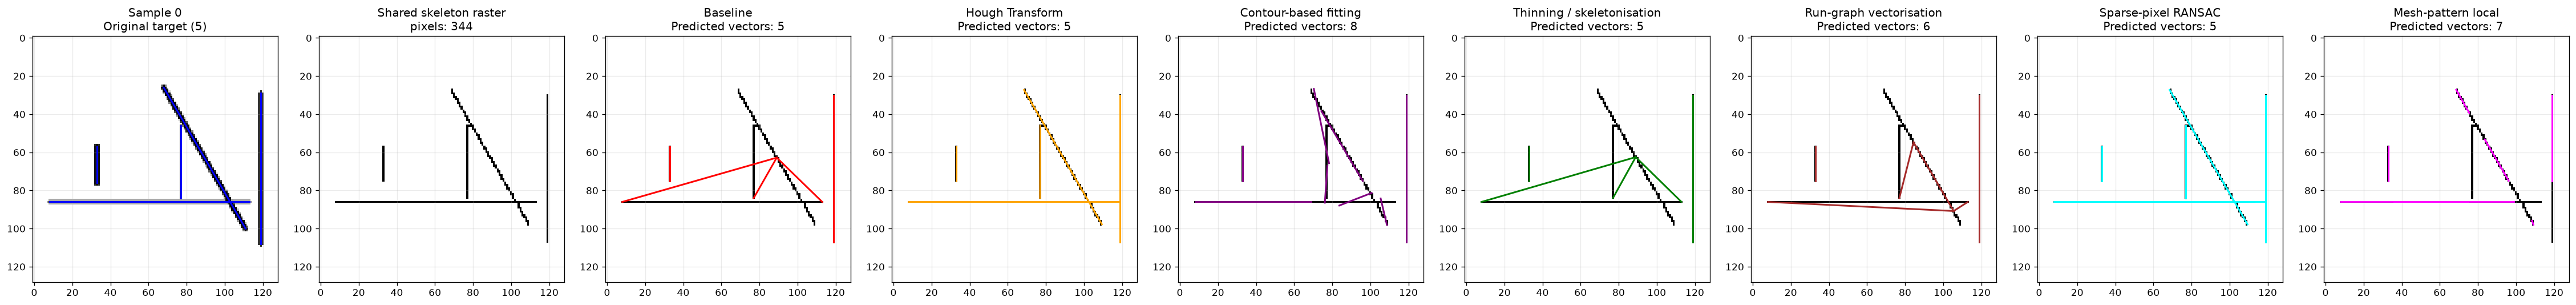

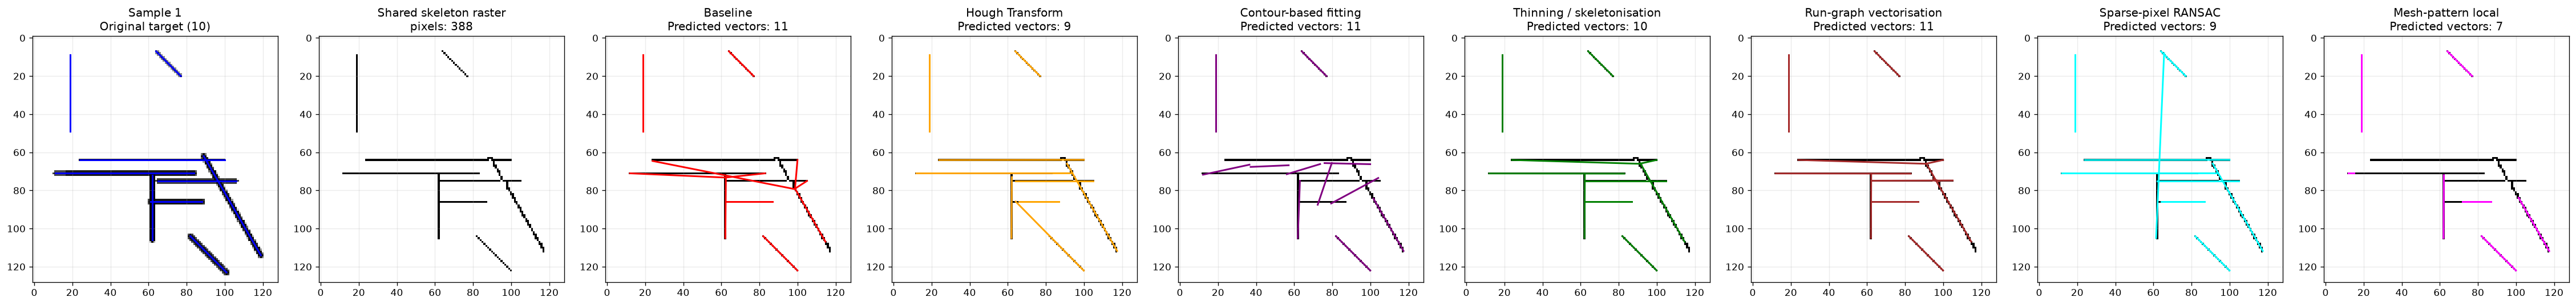

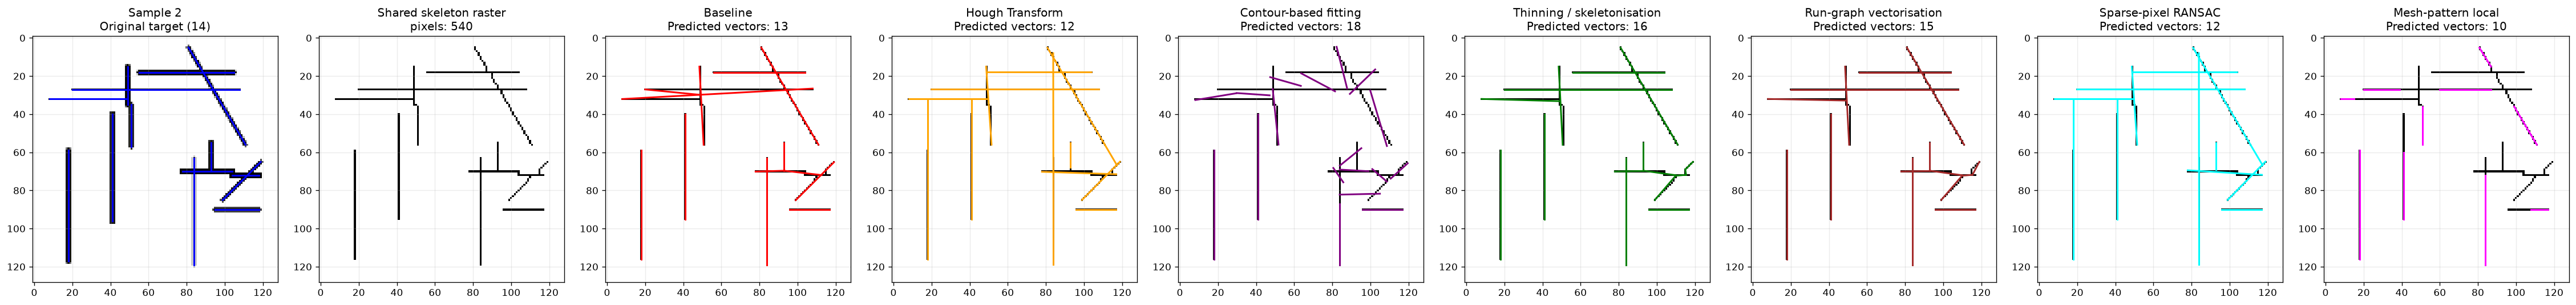

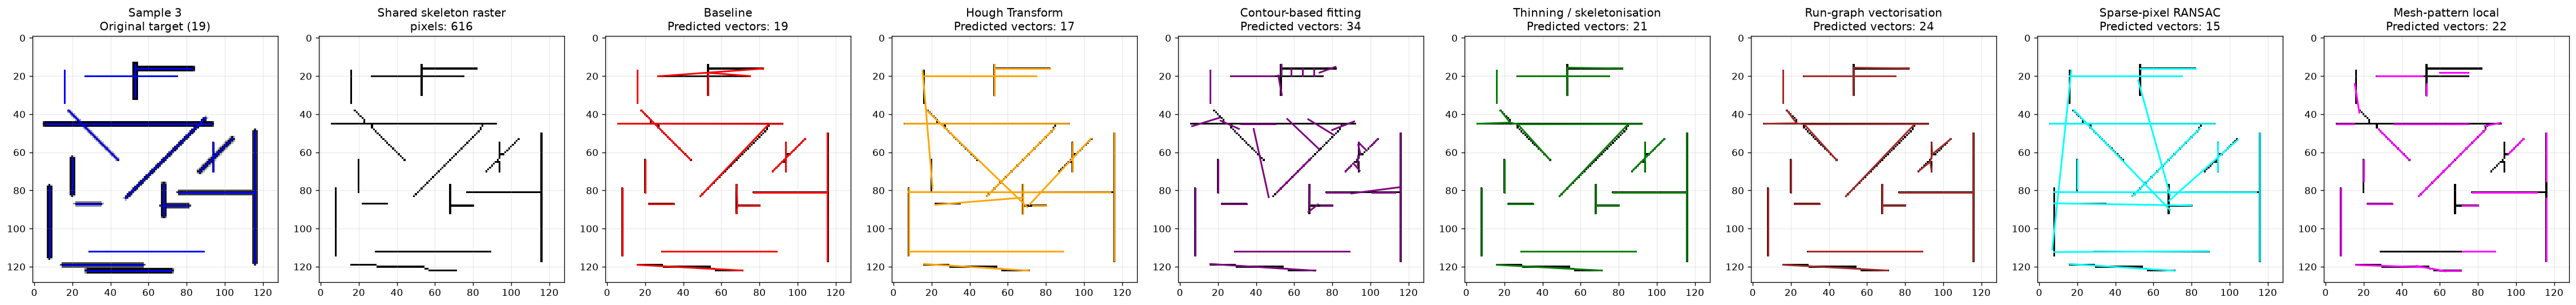

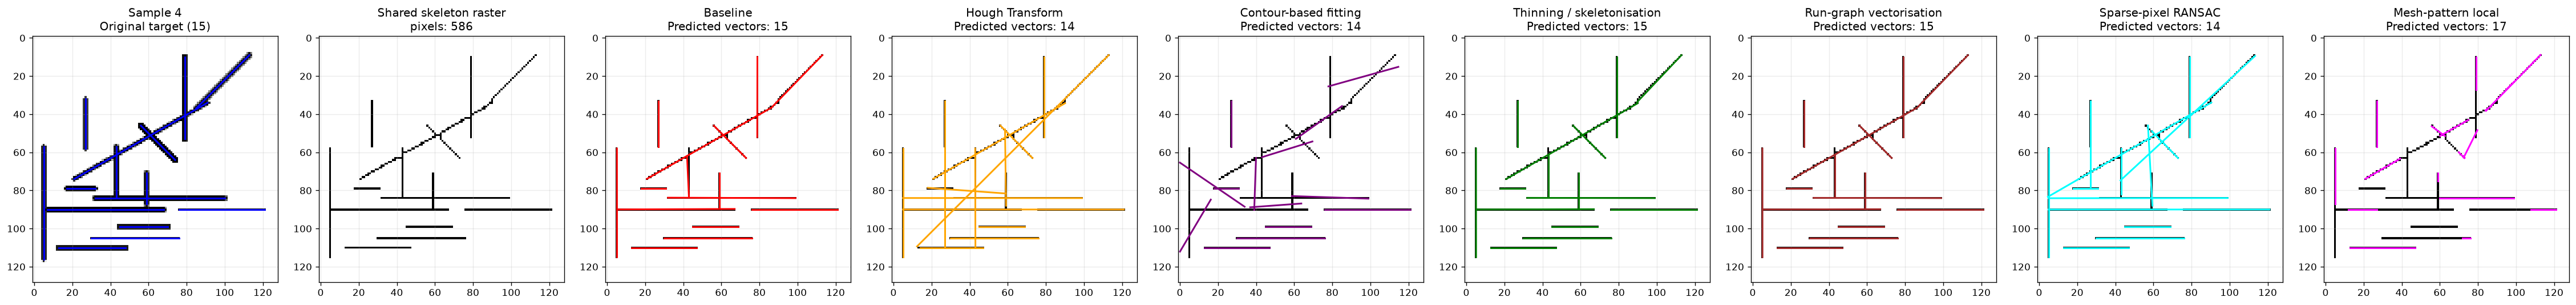

In [13]:

def draw_vectors(ax, image, vectors, title, colour='red'):
    ax.imshow(image, cmap='gray', vmin=0, vmax=1, interpolation='nearest')
    for x0, y0, x1, y1 in vectors:
        ax.plot([x0, x1], [y0, y1], color=colour, linewidth=1.8)
    ax.set_title(title)
    ax.set_xlim(-1, IMG_SIZE)
    ax.set_ylim(IMG_SIZE, -1)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.25)


NUM_PREVIEWS = 5          # Change this to 1, 3, 10, 20, etc.
START_SAMPLE_INDEX = 0    # First sample to preview

# Use this instead if you want exact sample numbers.
# Example: SAMPLE_INDICES = [0, 4, 12, 20]
SAMPLE_INDICES = None


PREVIEW_COLOURS = {
    'Original target vectors': 'blue',
    'baseline_on_shared_skeleton': 'red',
    'hough_transform_on_shared_skeleton': 'orange',
    'contour_based_fitting_on_shared_skeleton': 'purple',
    'thinning_skeletonisation_graph_tracing_on_shared_skeleton': 'green',
    'run_graph_vectorisation_on_shared_skeleton': 'brown',
    'sparse_pixel_ransac_vectorisation_on_shared_skeleton': 'cyan',
    'mesh_pattern_local_vectorisation_on_shared_skeleton': 'magenta',
}


def method_title(method_name):
    return METHOD_DISPLAY_NAMES.get(method_name, method_name.replace('_', ' '))


def show_method_comparison(sample_idx=0):
    raw_image = test_images[sample_idx]
    preprocessed_image = test_images_preprocessed[sample_idx]
    original_vectors = test_vectors[sample_idx]
    prep = test_preprocess_debug[sample_idx]

    method_names = list(METHODS_TO_COMPARE.keys())
    ncols = 2 + len(method_names)
    fig, ax = plt.subplots(1, ncols, figsize=(4.2 * ncols, 4.5), dpi=120)

    draw_vectors(
        ax[0],
        raw_image,
        original_vectors,
        f'Sample {sample_idx}\nOriginal target ({len(original_vectors)})',
        PREVIEW_COLOURS['Original target vectors'],
    )

    ax[1].imshow(preprocessed_image, cmap='gray', vmin=0, vmax=1, interpolation='nearest')
    ax[1].set_title(
        'Shared skeleton raster\n'
        f'pixels: {prep["processed_stroke_pixels"]}'
    )
    ax[1].set_xlim(-1, IMG_SIZE)
    ax[1].set_ylim(IMG_SIZE, -1)
    ax[1].set_aspect('equal')
    ax[1].grid(True, alpha=0.25)

    for col, method_name in enumerate(method_names, start=2):
        result = comparison_outputs[sample_idx][method_name]
        vectors = result['vectors']
        draw_vectors(
            ax[col],
            preprocessed_image,
            vectors,
            f'{method_title(method_name)}\nPredicted vectors: {len(vectors)}',
            PREVIEW_COLOURS.get(method_name, 'red'),
        )

    plt.tight_layout()
    plt.show()


def show_multiple_method_comparisons(
    num_previews=5,
    start_sample_index=0,
    sample_indices=None,
):
    if sample_indices is None:
        sample_indices = range(
            start_sample_index,
            start_sample_index + num_previews,
        )
    else:
        sample_indices = list(sample_indices)

    for sample_idx in sample_indices:
        show_method_comparison(sample_idx)


show_multiple_method_comparisons(
    num_previews=NUM_PREVIEWS,
    start_sample_index=START_SAMPLE_INDEX,
    sample_indices=SAMPLE_INDICES,
)


In [21]:
OUTPUT_DIR = Path("classic-learning")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def save_method_comparison_multipage_pdf(
    num_previews=10,
    start_sample_index=0,
    sample_indices=None,
    output_name="classic_methods_samples_0_to_9_large",
    dpi=200,
    cell_width=4.2,
    cell_height=4.5,
):
    if sample_indices is None:
        sample_indices = list(range(start_sample_index, start_sample_index + num_previews))
    else:
        sample_indices = list(sample_indices)

    method_names = list(METHODS_TO_COMPARE.keys())
    ncols = 2 + len(method_names)

    pdf_path = OUTPUT_DIR / f"{output_name}.pdf"

    with PdfPages(pdf_path) as pdf:
        for sample_idx in sample_indices:
            fig, ax = plt.subplots(
                1,
                ncols,
                figsize=(cell_width * ncols, cell_height),
                dpi=dpi,
                squeeze=False,
            )

            ax = ax[0]

            raw_image = test_images[sample_idx]
            preprocessed_image = test_images_preprocessed[sample_idx]
            original_vectors = test_vectors[sample_idx]
            prep = test_preprocess_debug[sample_idx]

            draw_vectors(
                ax[0],
                raw_image,
                original_vectors,
                f"Sample {sample_idx}\nOriginal target ({len(original_vectors)})",
                PREVIEW_COLOURS["Original target vectors"],
            )

            ax[1].imshow(
                preprocessed_image,
                cmap="gray",
                vmin=0,
                vmax=1,
                interpolation="nearest",
            )
            ax[1].set_title(
                "Shared skeleton raster\n"
                f'pixels: {prep["processed_stroke_pixels"]}'
            )
            ax[1].set_xlim(-1, IMG_SIZE)
            ax[1].set_ylim(IMG_SIZE, -1)
            ax[1].set_aspect("equal")
            ax[1].grid(True, alpha=0.25)

            for col, method_name in enumerate(method_names, start=2):
                result = comparison_outputs[sample_idx][method_name]
                vectors = result["vectors"]

                draw_vectors(
                    ax[col],
                    preprocessed_image,
                    vectors,
                    f"{method_title(method_name)}\nPredicted vectors: {len(vectors)}",
                    PREVIEW_COLOURS.get(method_name, "red"),
                )

            plt.tight_layout()
            pdf.savefig(fig, bbox_inches="tight")
            plt.close(fig)

            print(f"Saved sample {sample_idx}")

    print(f"\nSaved zoomable PDF:")
    print(pdf_path)

    return pdf_path

In [22]:
save_method_comparison_multipage_pdf(
    num_previews=10,
    start_sample_index=0,
    output_name="classic_methods_samples_0_to_9_large",
    dpi=200,
)

Saved sample 0
Saved sample 1
Saved sample 2
Saved sample 3
Saved sample 4
Saved sample 5
Saved sample 6
Saved sample 7
Saved sample 8
Saved sample 9

Saved zoomable PDF:
classic-learning\classic_methods_samples_0_to_9_large.pdf


WindowsPath('classic-learning/classic_methods_samples_0_to_9_large.pdf')

## Layered SVG export for all comparison methods

This creates Inkscape-compatible SVG files in `classic-learning`. Each method is saved as a separate layer, so you can switch methods on/off visually.


In [14]:
import re
import xml.etree.ElementTree as ET

SVG_NS = 'http://www.w3.org/2000/svg'
INKSCAPE_NS = 'http://www.inkscape.org/namespaces/inkscape'
ET.register_namespace('', SVG_NS)
ET.register_namespace('inkscape', INKSCAPE_NS)

EXPORT_DIR = Path('classic-learning')
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

LAYER_COLOURS = {
    'Original target vectors': '#1f77b4',
    'baseline_on_shared_skeleton': '#d62728',
    'hough_transform_on_shared_skeleton': '#ff7f0e',
    'contour_based_fitting_on_shared_skeleton': '#9467bd',
    'thinning_skeletonisation_graph_tracing_on_shared_skeleton': '#2ca02c',
    'run_graph_vectorisation_on_shared_skeleton': '#8c564b',
    'sparse_pixel_ransac_vectorisation_on_shared_skeleton': '#17becf',
    'mesh_pattern_local_vectorisation_on_shared_skeleton': '#e377c2',
}


def safe_layer_id(name):
    return re.sub(r'[^A-Za-z0-9_\-]+', '_', name).strip('_').lower()


def add_line_layer(svg, layer_name, vectors, colour, stroke_width=1.0, visible=True):
    layer = ET.SubElement(svg, f'{{{SVG_NS}}}g', {
        'id': safe_layer_id(layer_name),
        f'{{{INKSCAPE_NS}}}groupmode': 'layer',
        f'{{{INKSCAPE_NS}}}label': layer_name,
        'stroke': colour,
        'stroke-width': str(stroke_width),
        'fill': 'none',
        'stroke-linecap': 'round',
        'stroke-linejoin': 'round',
        'style': 'display:inline' if visible else 'display:none',
    })

    ET.SubElement(layer, f'{{{SVG_NS}}}title').text = layer_name

    for x0, y0, x1, y1 in vectors:
        ET.SubElement(layer, f'{{{SVG_NS}}}line', {
            'x1': f'{x0:.3f}',
            'y1': f'{y0:.3f}',
            'x2': f'{x1:.3f}',
            'y2': f'{y1:.3f}',
        })

    return layer


def export_all_methods_svg(sample_idx=0, filename=None, include_background=True):
    if filename is None:
        filename = EXPORT_DIR / f'sample_{sample_idx}_classic_methods_vector_comparison.svg'

    scale = 6

    svg = ET.Element(f'{{{SVG_NS}}}svg', {
        'width': str(IMG_SIZE * scale),
        'height': str(IMG_SIZE * scale),
        'viewBox': f'0 0 {IMG_SIZE} {IMG_SIZE}',
        'version': '1.1',
    })

    if include_background:
        background = ET.SubElement(svg, f'{{{SVG_NS}}}g', {
            'id': 'background',
            f'{{{INKSCAPE_NS}}}groupmode': 'layer',
            f'{{{INKSCAPE_NS}}}label': 'Background',
            'style': 'display:inline',
        })

        ET.SubElement(background, f'{{{SVG_NS}}}rect', {
            'x': '0',
            'y': '0',
            'width': str(IMG_SIZE),
            'height': str(IMG_SIZE),
            'fill': 'white',
        })

    add_line_layer(
        svg,
        'Original target vectors',
        test_vectors[sample_idx],
        LAYER_COLOURS['Original target vectors'],
        stroke_width=1.3,
    )

    for method_name in METHODS_TO_COMPARE.keys():
        add_line_layer(
            svg,
            METHOD_DISPLAY_NAMES.get(method_name, method_name),
            comparison_outputs[sample_idx][method_name]['vectors'],
            LAYER_COLOURS.get(method_name, '#000000'),
            stroke_width=1.0,
        )

    filename = Path(filename)
    ET.ElementTree(svg).write(filename, encoding='utf-8', xml_declaration=True)

    print(f'Saved layered SVG: {filename}')
    return filename


NUM_OUTPUT_EXAMPLES = 10
SAMPLE_INDICES = None

if SAMPLE_INDICES is None:
    SAMPLE_INDICES = range(min(NUM_OUTPUT_EXAMPLES, len(test_images)))

exported_svgs = [
    export_all_methods_svg(i)
    for i in SAMPLE_INDICES
]

exported_svgs


Saved layered SVG: classic-learning\sample_0_classic_methods_vector_comparison.svg
Saved layered SVG: classic-learning\sample_1_classic_methods_vector_comparison.svg
Saved layered SVG: classic-learning\sample_2_classic_methods_vector_comparison.svg
Saved layered SVG: classic-learning\sample_3_classic_methods_vector_comparison.svg
Saved layered SVG: classic-learning\sample_4_classic_methods_vector_comparison.svg
Saved layered SVG: classic-learning\sample_5_classic_methods_vector_comparison.svg
Saved layered SVG: classic-learning\sample_6_classic_methods_vector_comparison.svg
Saved layered SVG: classic-learning\sample_7_classic_methods_vector_comparison.svg
Saved layered SVG: classic-learning\sample_8_classic_methods_vector_comparison.svg
Saved layered SVG: classic-learning\sample_9_classic_methods_vector_comparison.svg


[WindowsPath('classic-learning/sample_0_classic_methods_vector_comparison.svg'),
 WindowsPath('classic-learning/sample_1_classic_methods_vector_comparison.svg'),
 WindowsPath('classic-learning/sample_2_classic_methods_vector_comparison.svg'),
 WindowsPath('classic-learning/sample_3_classic_methods_vector_comparison.svg'),
 WindowsPath('classic-learning/sample_4_classic_methods_vector_comparison.svg'),
 WindowsPath('classic-learning/sample_5_classic_methods_vector_comparison.svg'),
 WindowsPath('classic-learning/sample_6_classic_methods_vector_comparison.svg'),
 WindowsPath('classic-learning/sample_7_classic_methods_vector_comparison.svg'),
 WindowsPath('classic-learning/sample_8_classic_methods_vector_comparison.svg'),
 WindowsPath('classic-learning/sample_9_classic_methods_vector_comparison.svg')]